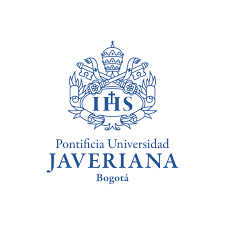
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Métricas y Machine Learning en PySpark**

**Autor**: Andres Jacobo Urrea Ochoa

**Fecha de Inicio**: 28 de Abril del 2026

**Fecha actual**: 12 de Mayo del 2026


## **Objetivos**
- Desarrollar un pipeline completo de clasificación binaria sobre el  
  dataset Bank Marketing utilizando Apache Spark en un modo clúster distribuido
- Utilizar técnicas de análisis exploratorio con el fin de descubrir los predictores más relevantes que influyen en la suscripción de depósitos bancarios
- Entrenar y comparar 6 modelos de Machine Learning evaluando mediante su desempeño y usando medidas tradicionales de clasificación
- Elegir el modelo mejor evaluado en una herramienta para la segmentación de clientes por score de probabilidad


In [1]:
## Importar bibliotecas generales
import numpy as nm                                      # Operaciones numéricas y manejo de arrays
import pandas as pd                                     # Manipulación y análisis de datos en DataFrames
import matplotlib.pyplot as plt                         # Visualización y generación de gráficas
import seaborn as sns                                   # Visualización estadística 

## Bibliotecas especializadas
from pylab import * # Biblioteca para uso interactivo de matplotlib

import findspark 
findspark.init()  # Localiza la instalación de Spark en el sistema para que Python pueda usarla

from pyspark.sql import functions as F                   # Funciones SQL
from pyspark import SparkConf, SparkContext              # Configuración y contexto base de Spark
from pyspark.sql import SQLContext, SparkSession, Row    # Sesión SQL, contexto SQL y estructura de filas
from pyspark.sql.types import *                          # Tipos de datos

from pyspark.ml.feature import StringIndexer, OneHotEncoder                                              # Codificación de variables categóricas
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator       # Evaluación para clasificación
from pyspark.ml import Pipeline                                                                          # Encadenamiento de etapas de ML en un flujo único
from sklearn.metrics import roc_curve, auc                                                               # Curva ROC y cálculo del área bajo la curva 

In [2]:
### Se requiere levantar la sesión para Trabajar con los Servicios
### Basados en SPARK: Procesamiento Paralelo y Distribuido sobre Grandes Volumenes de Datos
configura = SparkConf()
configura.setAppName("Banca_Urrea_SPARK")                                           #--- Nombre de la aplicación
configura.set("spark.scheduler.mode","FAIR")                                        #---Configuracion de tipo "FAIR" para que sea justo y equitativo. 
                                                                                    #---Se requiere que multiples usuarios tengan recursos concurrentemente
configura.set("spark.scheduler.allocation","/Almacen/Spark/conf/fairscheduler.xml") #---Ubicación xml de la configuración FAIR
configura.setMaster("spark://10.43.97.207:7077")                                    #---Se configura en la dirección del MASTER
sparkB = SparkSession.builder.config(conf=configura).getOrCreate()                  #---Se crea la sesión
print("Sesión creada: Banca Urrea")
sparkB

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/23 12:09:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Sesión creada: Banca Urrea


In [3]:
### Importar el Dataset
df00 = sparkB.read.format("csv").option("header","true").option("sep",";").load("bank-full.csv")

# Muestra las primeras 5 filas del DataFrame 
df00.show(5)

[Stage 1:>                                                          (0 + 1) / 1]

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management|married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician| single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur|married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar|married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown| single|  unknown|     no|      1|     no|  no|unknown|  5|  may|     19

## **Descripción de datos:**
* AGE: Edad del cliente (años).
* JOB: Tipo de trabajo del cliente.
* MARITAL: Estado civil del cliente (categórico: casado, soltero).
* EDUCATION: Nivel educativo del cliente.
* DEFAULT: Indica si el cliente tiene crédito en incumplimiento (binario: sí/no).
* BALANCE: Balance promedio anual del cliente.
* HOUSING: Indica si el cliente tiene un préstamo hipotecario (binario: sí/no).
* LOAN: Indica si el cliente tiene un préstamo personal (binario: sí/no).
* CONTACT: Tipo de comunicación utilizada para contactar al cliente.
* DAY_OF_WEEK: Último día de la semana en que se contactó al cliente.
* MONTH: Último mes del año en que se contactó al cliente (categórico: enero, febrero,...., diciembre).
* DURATION: Duración de la última llamada en segundos.
* CAMPAIGN: Número de contactos realizados durante esta campaña para este cliente.
* PDAYS: Número de días transcurridos desde el último contacto en una campaña previa (-1 indica que no fue contactado anteriormente).
* PREVIOUS: Número de contactos realizados antes de esta campaña para este cliente.
* POUTCOME: Resultado de la campaña de marketing anterior.
* Y: Variable objetivo. Indica si el cliente se suscribió a un depósito a plazo (binario: sí/no).


In [4]:
### Cantidad de datos
print(f"Se tiene un total de  {df00.count()} registros")

[Stage 4:>                                                          (0 + 1) / 1]

Se tiene un total de  45211 registros


### Comentarios:
- Se observa que todos los datos se encuentran en tipo "String"
- Se considera la el cambio de tipo de datos a entero
- Se logra observar que la última columna es ETIQUETA

In [5]:
##Conocimiento de las columnas
df00.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

In [6]:
# Lista de nombres originales 
NomOriginal = ['age',
 'job',
 'marital',
 'education',
 'default',
 'Balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

# Lista de nombres nuevos
NomNueva = ['edad',
 'trabajo',
 'Estado_Civil',
 'Educacion',
 'Credito_Incumplimiento',
 'Balance',
 'Prestamo_Hipotecario',
 'Prestamo_Personal',
 'Comunicacion',
 'Dia',
 'Mes',
 'Duracion',
 'Contactos_en_Campaña',
 'Numero_dias',
 'Contactos_Previos',
 'Campaña_Marketing',
 'Suscripcion']

# Copia del DataFrame original para no modificar df00 directamente 
df01 = df00
# Aplica el renombrado columna por columna recorriendo ambas listas simultáneamente
for antes, nuevo in zip(NomOriginal, NomNueva):
    df01 = df01.withColumnRenamed(antes, nuevo)
    
# Verifica que los nuevos nombres se hayan aplicado correctamente
df01.columns

['edad',
 'trabajo',
 'Estado_Civil',
 'Educacion',
 'Credito_Incumplimiento',
 'Balance',
 'Prestamo_Hipotecario',
 'Prestamo_Personal',
 'Comunicacion',
 'Dia',
 'Mes',
 'Duracion',
 'Contactos_en_Campaña',
 'Numero_dias',
 'Contactos_Previos',
 'Campaña_Marketing',
 'Suscripcion']

In [7]:
### Las siguientes columnas pasan a ser "INT"
colINT = ['edad', 'Balance','Dia', 'Duracion','Contactos_en_Campaña','Numero_dias','Contactos_Previos']

# Al leer un CSV en Spark, todas las columnas se infieren como String por defecto.
# Se usa .cast("int") para convertir cada columna numérica a otro tipo.
df02 = df01.withColumn("edad", df01.edad.cast("int"))
df02 = df02.withColumn("Balance", df02.Balance.cast("int"))
df02 = df02.withColumn("Dia", df02.Dia.cast("int"))
df02 = df02.withColumn("Duracion", df02.Duracion.cast("int"))
df02 = df02.withColumn("Contactos_en_Campaña", df02.Contactos_en_Campaña.cast("int"))
df02 = df02.withColumn("Numero_dias", df02.Numero_dias.cast("int"))
df02 = df02.withColumn("Contactos_Previos", df02.Contactos_Previos.cast("int"))

In [8]:
#Mostrar la estructura técnica del DataFrame
df02.printSchema()

root
 |-- edad: integer (nullable = true)
 |-- trabajo: string (nullable = true)
 |-- Estado_Civil: string (nullable = true)
 |-- Educacion: string (nullable = true)
 |-- Credito_Incumplimiento: string (nullable = true)
 |-- Balance: integer (nullable = true)
 |-- Prestamo_Hipotecario: string (nullable = true)
 |-- Prestamo_Personal: string (nullable = true)
 |-- Comunicacion: string (nullable = true)
 |-- Dia: integer (nullable = true)
 |-- Mes: string (nullable = true)
 |-- Duracion: integer (nullable = true)
 |-- Contactos_en_Campaña: integer (nullable = true)
 |-- Numero_dias: integer (nullable = true)
 |-- Contactos_Previos: integer (nullable = true)
 |-- Campaña_Marketing: string (nullable = true)
 |-- Suscripcion: string (nullable = true)



In [9]:
## Se revisa el balance del dataset. La idea es conocer si hay posibilidades de sesgo
total = df02.count()
df_Y = df02.groupBy("Suscripcion").count()  #Se cuenta cuántos registros hay por cada clase

auxPD = df_Y.withColumn("Porcentaje", df_Y["count"]*100/total)  ## Se agrega una columna de porcentaje para visualizar la proporción de cada clase
auxPD.show() 

[Stage 8:=============================>                             (1 + 1) / 2]

+-----------+-----+------------------+
|Suscripcion|count|        Porcentaje|
+-----------+-----+------------------+
|         no|39922| 88.30151954170445|
|        yes| 5289|11.698480458295547|
+-----------+-----+------------------+



### Comentarios:
    - Al observar el balanceo sobre las etiquetas o la columna target se observa:
        -La clase minoritaria es "yes" con un 11.7% sobre el total
        -La clase mayoritaria es "no" con un 88.3% sobre el total
    -Esta variable es binaria, y es importante tener presente no crear un sesgo al tratar los modelos para hacer la predicción  

    - Esto puede provocar que:
        -El modelo aprenda a predecir casi siempre "no" y aún así tenga alta accuracy
        -Esto haria que las metricas de accuracy sean engañosas

In [10]:
## Se revisa de forma exahustiva las estadísticas completas del dataset
df02.describe().toPandas()

26/05/23 12:12:51 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,summary,edad,trabajo,Estado_Civil,Educacion,Credito_Incumplimiento,Balance,Prestamo_Hipotecario,Prestamo_Personal,Comunicacion,Dia,Mes,Duracion,Contactos_en_Campaña,Numero_dias,Contactos_Previos,Campaña_Marketing,Suscripcion
0,count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
1,mean,40.93621021432837,None,None,None,None,1362.2720576850766,None,None,None,15.80641879188693,None,258.1630797814691,2.763840658246887,40.19782796222158,0.5803233726305546,None,None
2,stddev,10.618762040975401,None,None,None,None,3044.7658291685243,None,None,None,8.322476153044589,None,257.5278122651712,3.0980208832791813,100.12874599059818,2.3034410449312164,None,None
3,min,18,admin.,divorced,primary,no,-8019,no,no,cellular,1,apr,0,1,-1,0,failure,no
4,max,95,unknown,single,unknown,yes,102127,yes,yes,unknown,31,sep,4918,63,871,275,unknown,yes


In [11]:
####Seleccionar solo las variables categoricas
col_cat = ['trabajo', 'Estado_Civil','Educacion', 'Credito_Incumplimiento', 'Prestamo_Hipotecario',
           'Prestamo_Personal', 'Comunicacion','Mes', 'Campaña_Marketing','Suscripcion']

#Se agrupa y se observa cada categoria
for col in col_cat:
    df02.groupBy(col).count().show()

+-------------+-----+
|      trabajo|count|
+-------------+-----+
|   management| 9458|
|      retired| 2264|
|      unknown|  288|
|self-employed| 1579|
|      student|  938|
|  blue-collar| 9732|
| entrepreneur| 1487|
|       admin.| 5171|
|   technician| 7597|
|     services| 4154|
|    housemaid| 1240|
|   unemployed| 1303|
+-------------+-----+

+------------+-----+
|Estado_Civil|count|
+------------+-----+
|    divorced| 5207|
|     married|27214|
|      single|12790|
+------------+-----+

+---------+-----+
|Educacion|count|
+---------+-----+
|  unknown| 1857|
| tertiary|13301|
|secondary|23202|
|  primary| 6851|
+---------+-----+

+----------------------+-----+
|Credito_Incumplimiento|count|
+----------------------+-----+
|                    no|44396|
|                   yes|  815|
+----------------------+-----+

+--------------------+-----+
|Prestamo_Hipotecario|count|
+--------------------+-----+
|                  no|20081|
|                 yes|25130|
+--------------------+

#### Se requiere observar en gráficas las variables númericas
    - Se agrupa cada categoria y se cuenta el numero de ocurrencias en cada grupo
    - Se grafica usando las graficas de histogramas
    - Permite visualizar la distribución de los datos y detectar sesgos o outliers

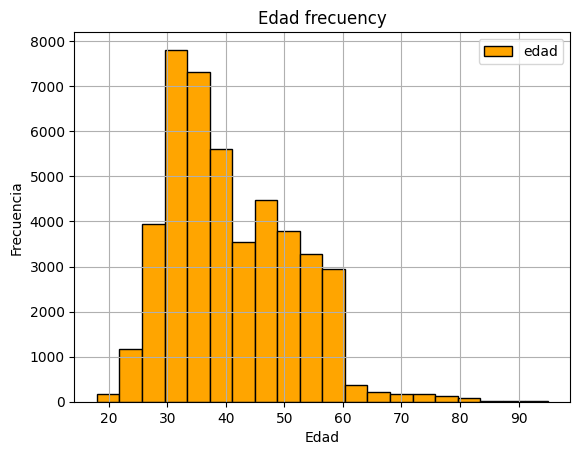

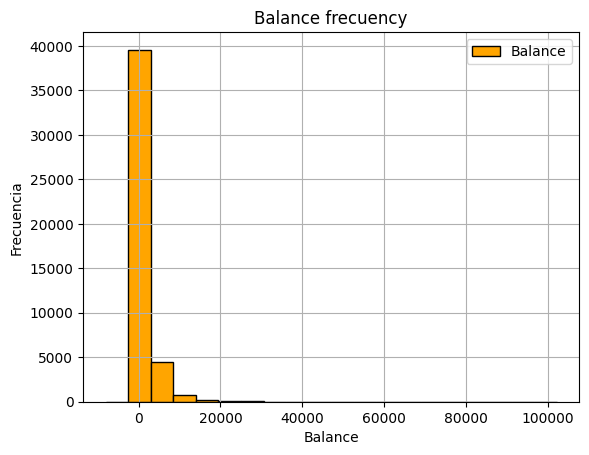

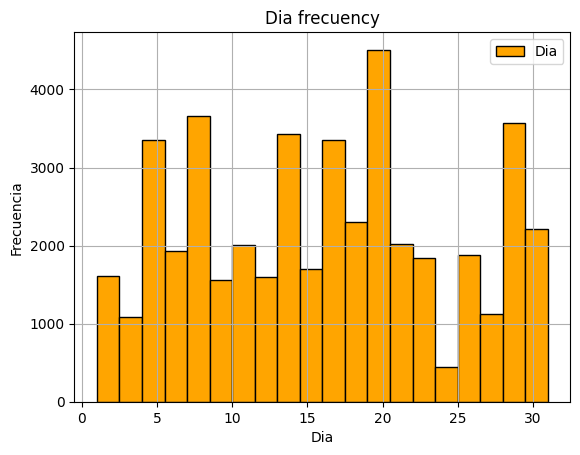

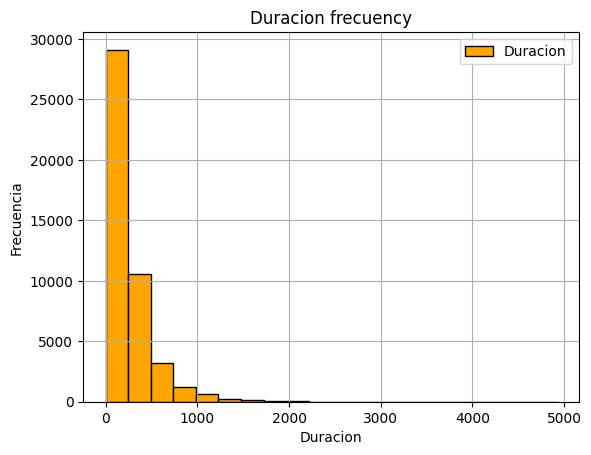

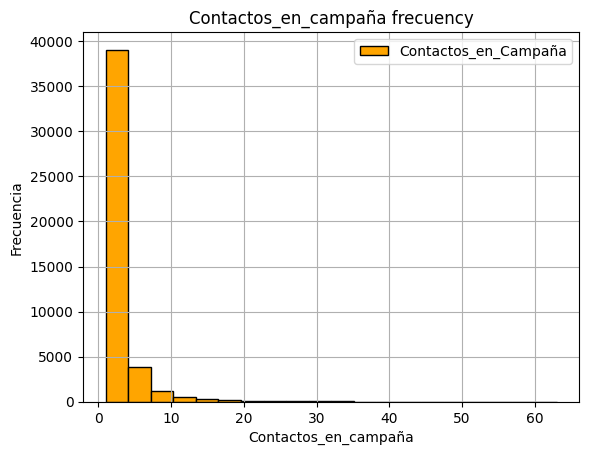

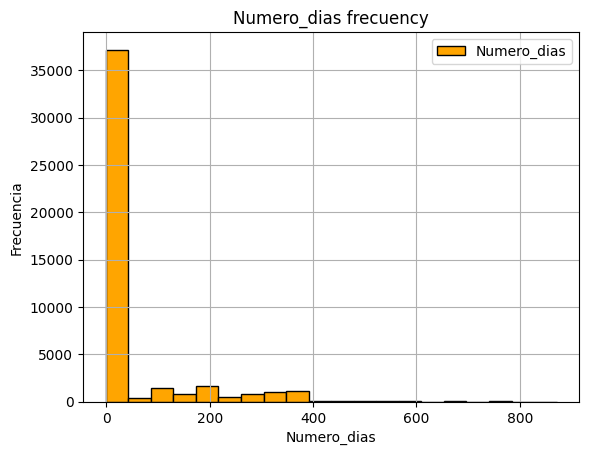

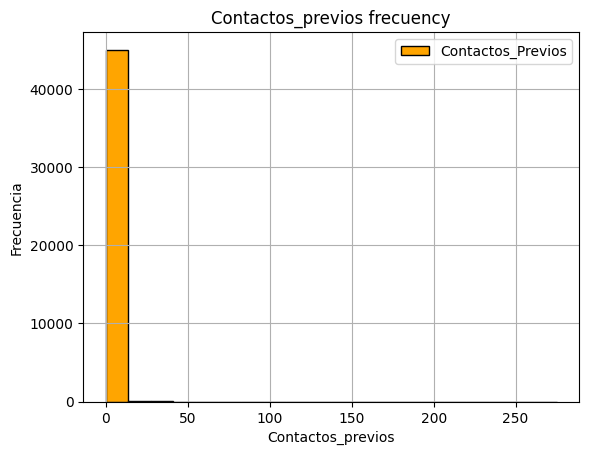

In [12]:
for col_int in colINT:
    histGra = df02.select(col_int).toPandas()
    histGra.plot(kind='hist', bins=20, edgecolor='black', color = 'orange')
    plt.ylabel('Frecuencia')
    plt.xlabel(col_int.capitalize())
    plt.title(f"{col_int.capitalize()} frecuency")
    plt.grid()
    plt.show()

#### Comentarios generales 
    - Se observa un ruido en el balance sobre la frecuencia de los datos, dado que pocas personas tienen mas de 102 mil euros
        - la mayoria de las personas tienen menos de mil euros
    - La población bancaria contactada tiene entre 25 y 40 años, con otro grupo relevante entre 45 y 55 años
        -Muy pocos clientes mayores de 70 años, lo que puede sesgar
    - Distribución relativamente uniforme a lo largo del mes
        -Picos alrededor del dia 20
        -Los días 24-25 presentan una caída significativa
        -No hay un patrón claro de concentración
    - La distribucion tiende a estar a la izquierda
        -La mayoría de las llamadas dura menos de 500 segundos
        -Esta variable tiene alta correlación con "y"
        -Existen casos atípicos que superan los 4,000 segundos 
    - La mayoría de clientes fue contactado entre 1 y 3 veces durante la campaña actual 
        - Existe una cola larga con casos extremos de hasta 60+ contactos
    -Existe un gran pico inicial en clientes contactados previamente 
        - Para quienes sí fueron contactados previamente, el intervalo más frecuente es entre 90 y 200 días

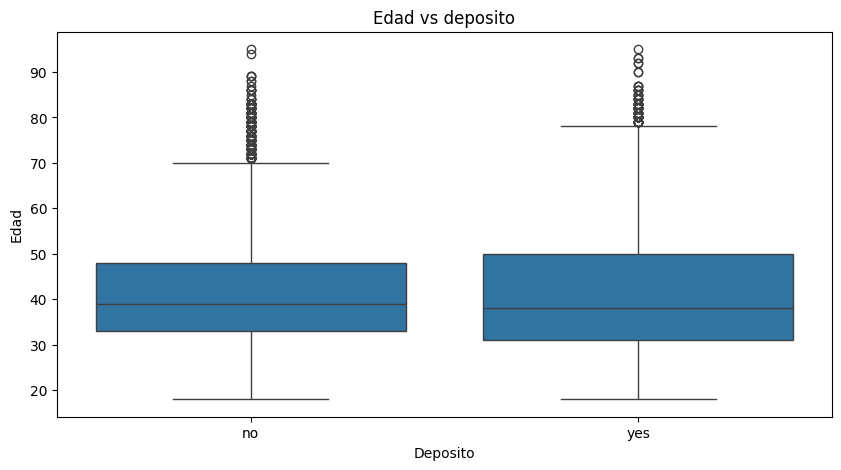

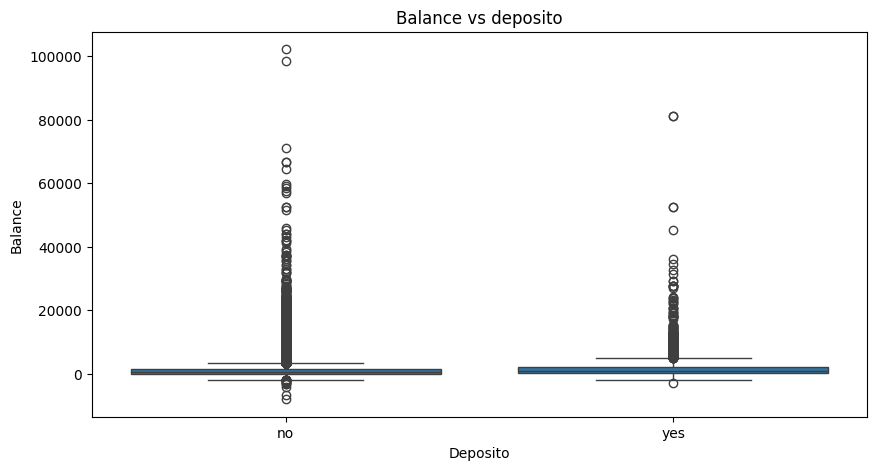

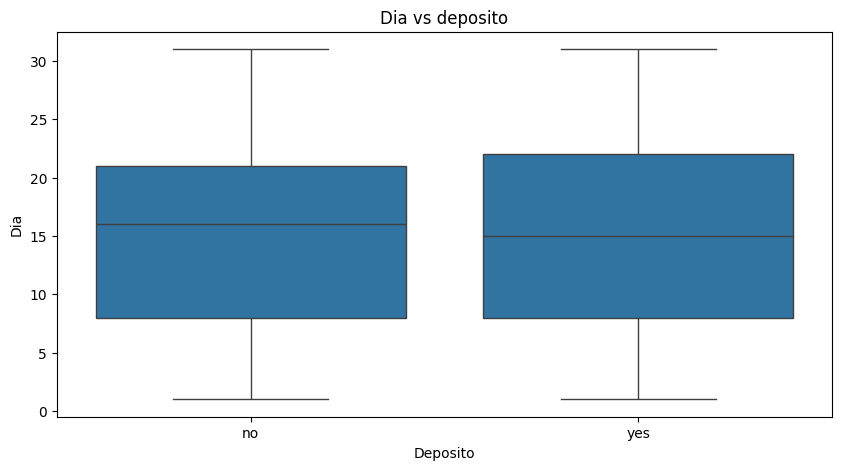

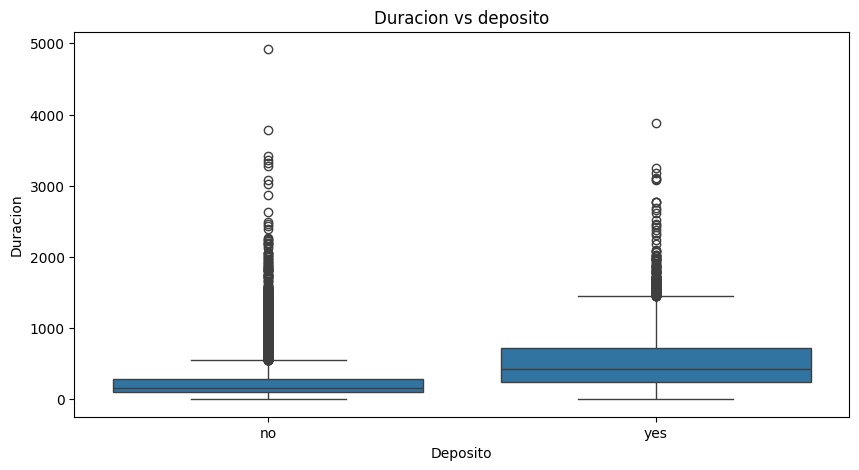

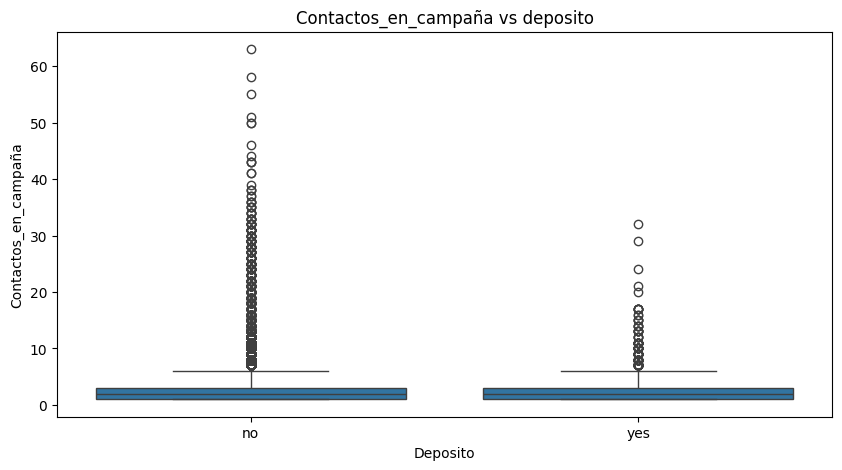

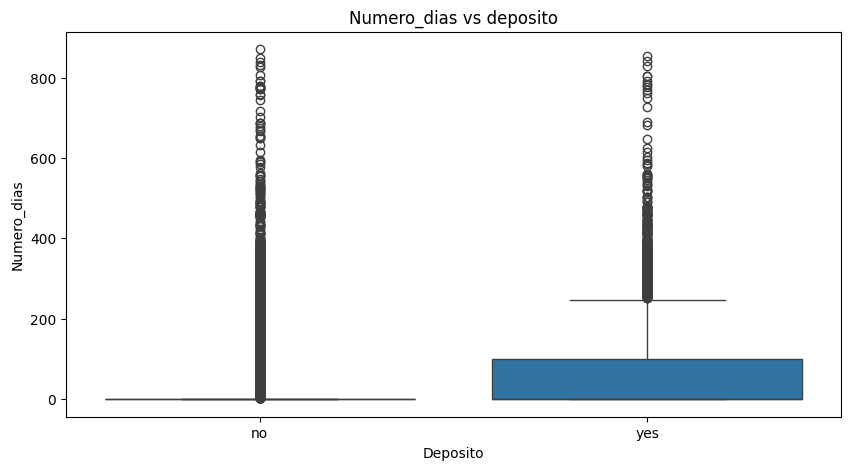

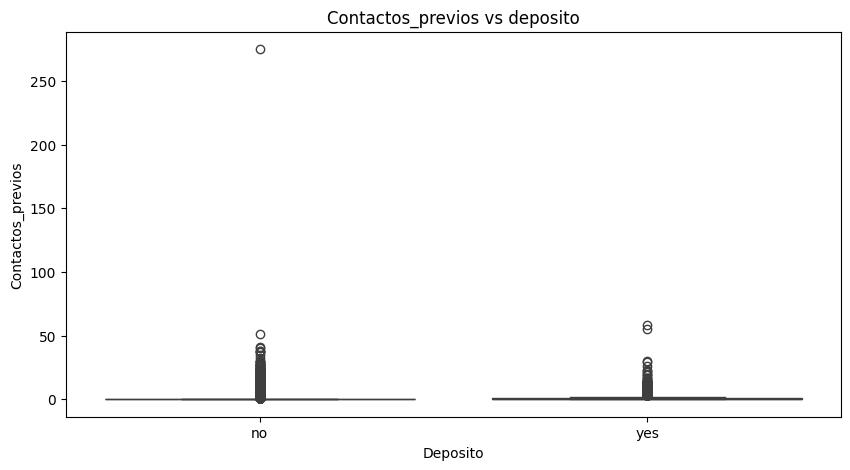

In [13]:
# Para cada variable numérica se genera un boxplot comparativo entre los dos grupos de la variable objetivo:
#   - "no"  cliente NO suscribió el depósito
#   - "yes" cliente SÍ suscribió el depósito

for col_int in colINT:
    plt.figure(figsize=(10,5))
    sns.boxplot(x='Suscripcion', y=col_int, data=df02.toPandas())
    plt.title(f"{col_int.capitalize()} vs deposito")
    plt.xlabel("Deposito")
    plt.ylabel(col_int.capitalize())
    plt.show()
    

#### Comentarios generales 
    -Ambos grupos tienen medianas similares, de aproximadamente 40 años, con IQR entre 30-50.
        -El grupo "yes" presenta una caja ligeramente más amplia hacia edades mayores,
        -Outliers presentes en ambos grupos por encima de los 75 años.

    - la mayoría de los clientes tiene saldos bajos sin importar su decisión
        -La clase "no" concentra los outliers más extremos, casi hasta ~100,000
        -"yes" tiene outliers más moderados
    
    -Las distribuciones de ambos grupos son prácticamente idénticas
        - Medianas alrededor del día 15-16 y rangos similares
        - No se observan diferencias importantes entre ambos
    
    - Diferencia mas marcada en la duracion
        - Grupo "no" tiene la mediana en aproximadamente 180 segundos
        - Grupo "yes" tiene la mediana en aproximadamente 450 segundos
        - Clientes que suscribieron tuvieron llamadas significativamente más largas
    
    - Ambos grupos tienen medianas de 2 contactos y cajas muy similares
        - La clase "no" concentra outliers mucho más extremos, que van hasta 63 contactos
         
         
    - El grupo "no" tiene la caja completamente colapsada en -1, que nunca ha contectado
        - "yes" muestra una caja con IQR entre 0 y 250 días
        - Clientes previamente contactados son mas propensos a suscribirse

    -Ambos grupos tienen medianas en 0 en depositos previos
        - El grupo "no" tiene un outlier extremo, 275 contactos previos
        - El grupo "yes"  tiene un poco de dispersión en la parte alta


### Entendimiento de los datos númericos 
    - Se requiere un objeto auxiliar con solo las columnas numericas 

In [14]:
### Las siguientes columnas se cambian a "INT"
colNum = ['edad', 'Balance','Dia', 'Duracion','Contactos_en_Campaña','Numero_dias','Contactos_Previos']
### Se requiere cambiar la columna "y" de si o no a 1 0
### Además, se requiere incorporarla al dataframe numérico

dfauxNum = df02.select(colNum + ['Suscripcion'])
dfauxNum = dfauxNum.withColumn('Suscripcion', F.when(dfauxNum['Suscripcion'] == 'yes', 1).otherwise(0))
dfauxNum.show(5)

+----+-------+---+--------+--------------------+-----------+-----------------+-----------+
|edad|Balance|Dia|Duracion|Contactos_en_Campaña|Numero_dias|Contactos_Previos|Suscripcion|
+----+-------+---+--------+--------------------+-----------+-----------------+-----------+
|  58|   2143|  5|     261|                   1|         -1|                0|          0|
|  44|     29|  5|     151|                   1|         -1|                0|          0|
|  33|      2|  5|      76|                   1|         -1|                0|          0|
|  47|   1506|  5|      92|                   1|         -1|                0|          0|
|  33|      1|  5|     198|                   1|         -1|                0|          0|
+----+-------+---+--------+--------------------+-----------+-----------------+-----------+
only showing top 5 rows



In [15]:
### El anterior dataframe auxiliar se convierte en un VectorAssembler de 'feature'
### 

from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.ml.stat import Correlation
ensamblador = VectorAssembler(inputCols=dfauxNum.columns, outputCol='features')
### Normalizado y Escalado 
dfNumVector = ensamblador.transform(dfauxNum).select('features')

### La matriz de correlación 
 - permite identificar relaciones lineales entre las variables numéricas.
 - representan correlación negativa fuerte. Valores próximos a 0 sugieren poca relación lineal.
 - Este análisis ayuda a comprender el comportamiento de las variables y detectar posibles redundancias antes del entrenamiento del modelo de clasificación.

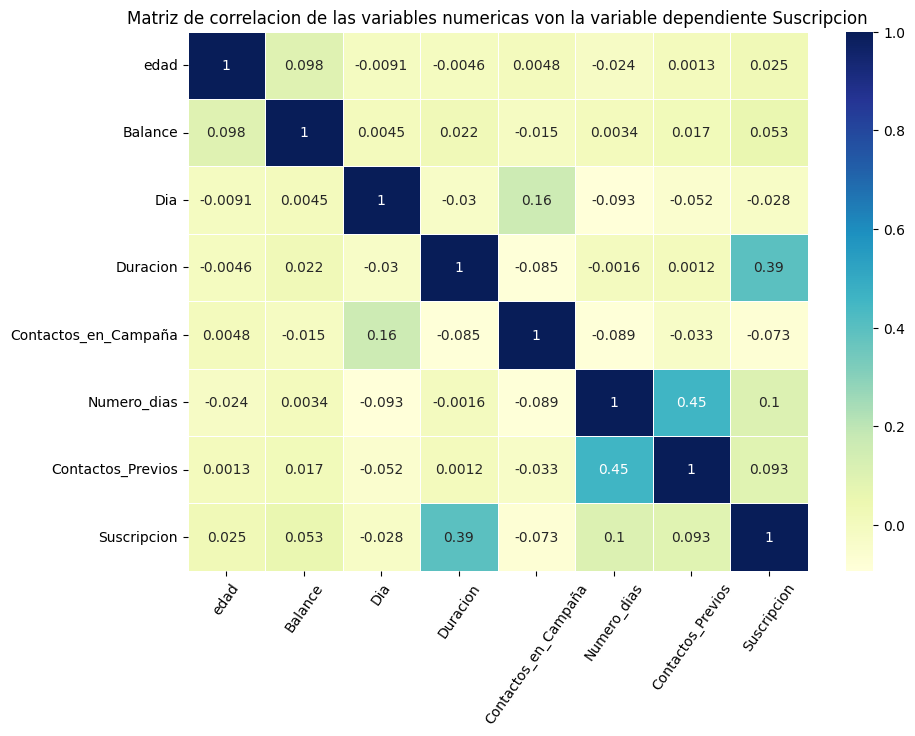

In [18]:
### Se grafica la matriz de correlación: se tiene en cuenta que los datos son ensamblados
matrizCorr = Correlation.corr(dfNumVector, 'features').head()

## Se procede a pintar la matriz de correlación
vectorCorr = matrizCorr[0].toArray()

#Se crea un objeto dataframe con el arreglo anterior de Correlación de Pearson
dfCorrelation = pd.DataFrame(vectorCorr, columns=dfauxNum.columns, index=dfauxNum.columns)

plt.figure(figsize=(10,7))
sns.heatmap(dfCorrelation, 
            annot=True, 
            cmap='YlGnBu', 
            linewidths=0.5)
plt.title("Matriz de correlacion de las variables numericas von la variable dependiente Suscripcion")
plt.xticks(rotation=55)
plt.yticks(rotation=0)
plt.show()


#### Comentarios generales 
    - Valores cercanos a 1 indican correlación positiva fuerte
    - Valores cercanos a -1 representan correlación negativa fuerte
    - Valores cercanos a 0 representan poca relación lineal

    - En el conjunto de datos no hay problemas de redundancia entre las variables independientes
    - La correlación más alta es de 0.45 entre la variable "pdays" y "previous"
        - si un cliente fue contactado previamenmte (previous)
        - es más probable que el número de días desde el último contacto (pdays) tenga un valor registrado

    - La variable edad y balance saldo tienen una correlación de apenas 0.10
        - El nivel de saldo en la cuenta no depende fuertemente de la edad del cliente en este dataset
    - En las demas variables la correlacion es muy cercana a 0
    
En conclusión, la matriz revela que las variables numéricas son generalmente independientes, destacando únicamente una relación positiva moderada (0.45) entre pdays y previous. Esta ausencia de correlaciones fuertes indica que no existe redundancia o multicolinealidad en el dataset, lo cual indica que cada variable aporta información única y diferenciada, facilitando una interpretación más clara y estable de los resultados

### PAIRPLOT 
- Para revisar relaciones entre variables numéricas
- Es una herramienta clave para detectar correlaciones, separabilidad entre clases y patrones visuales que orienten la selección de features para el modelo.

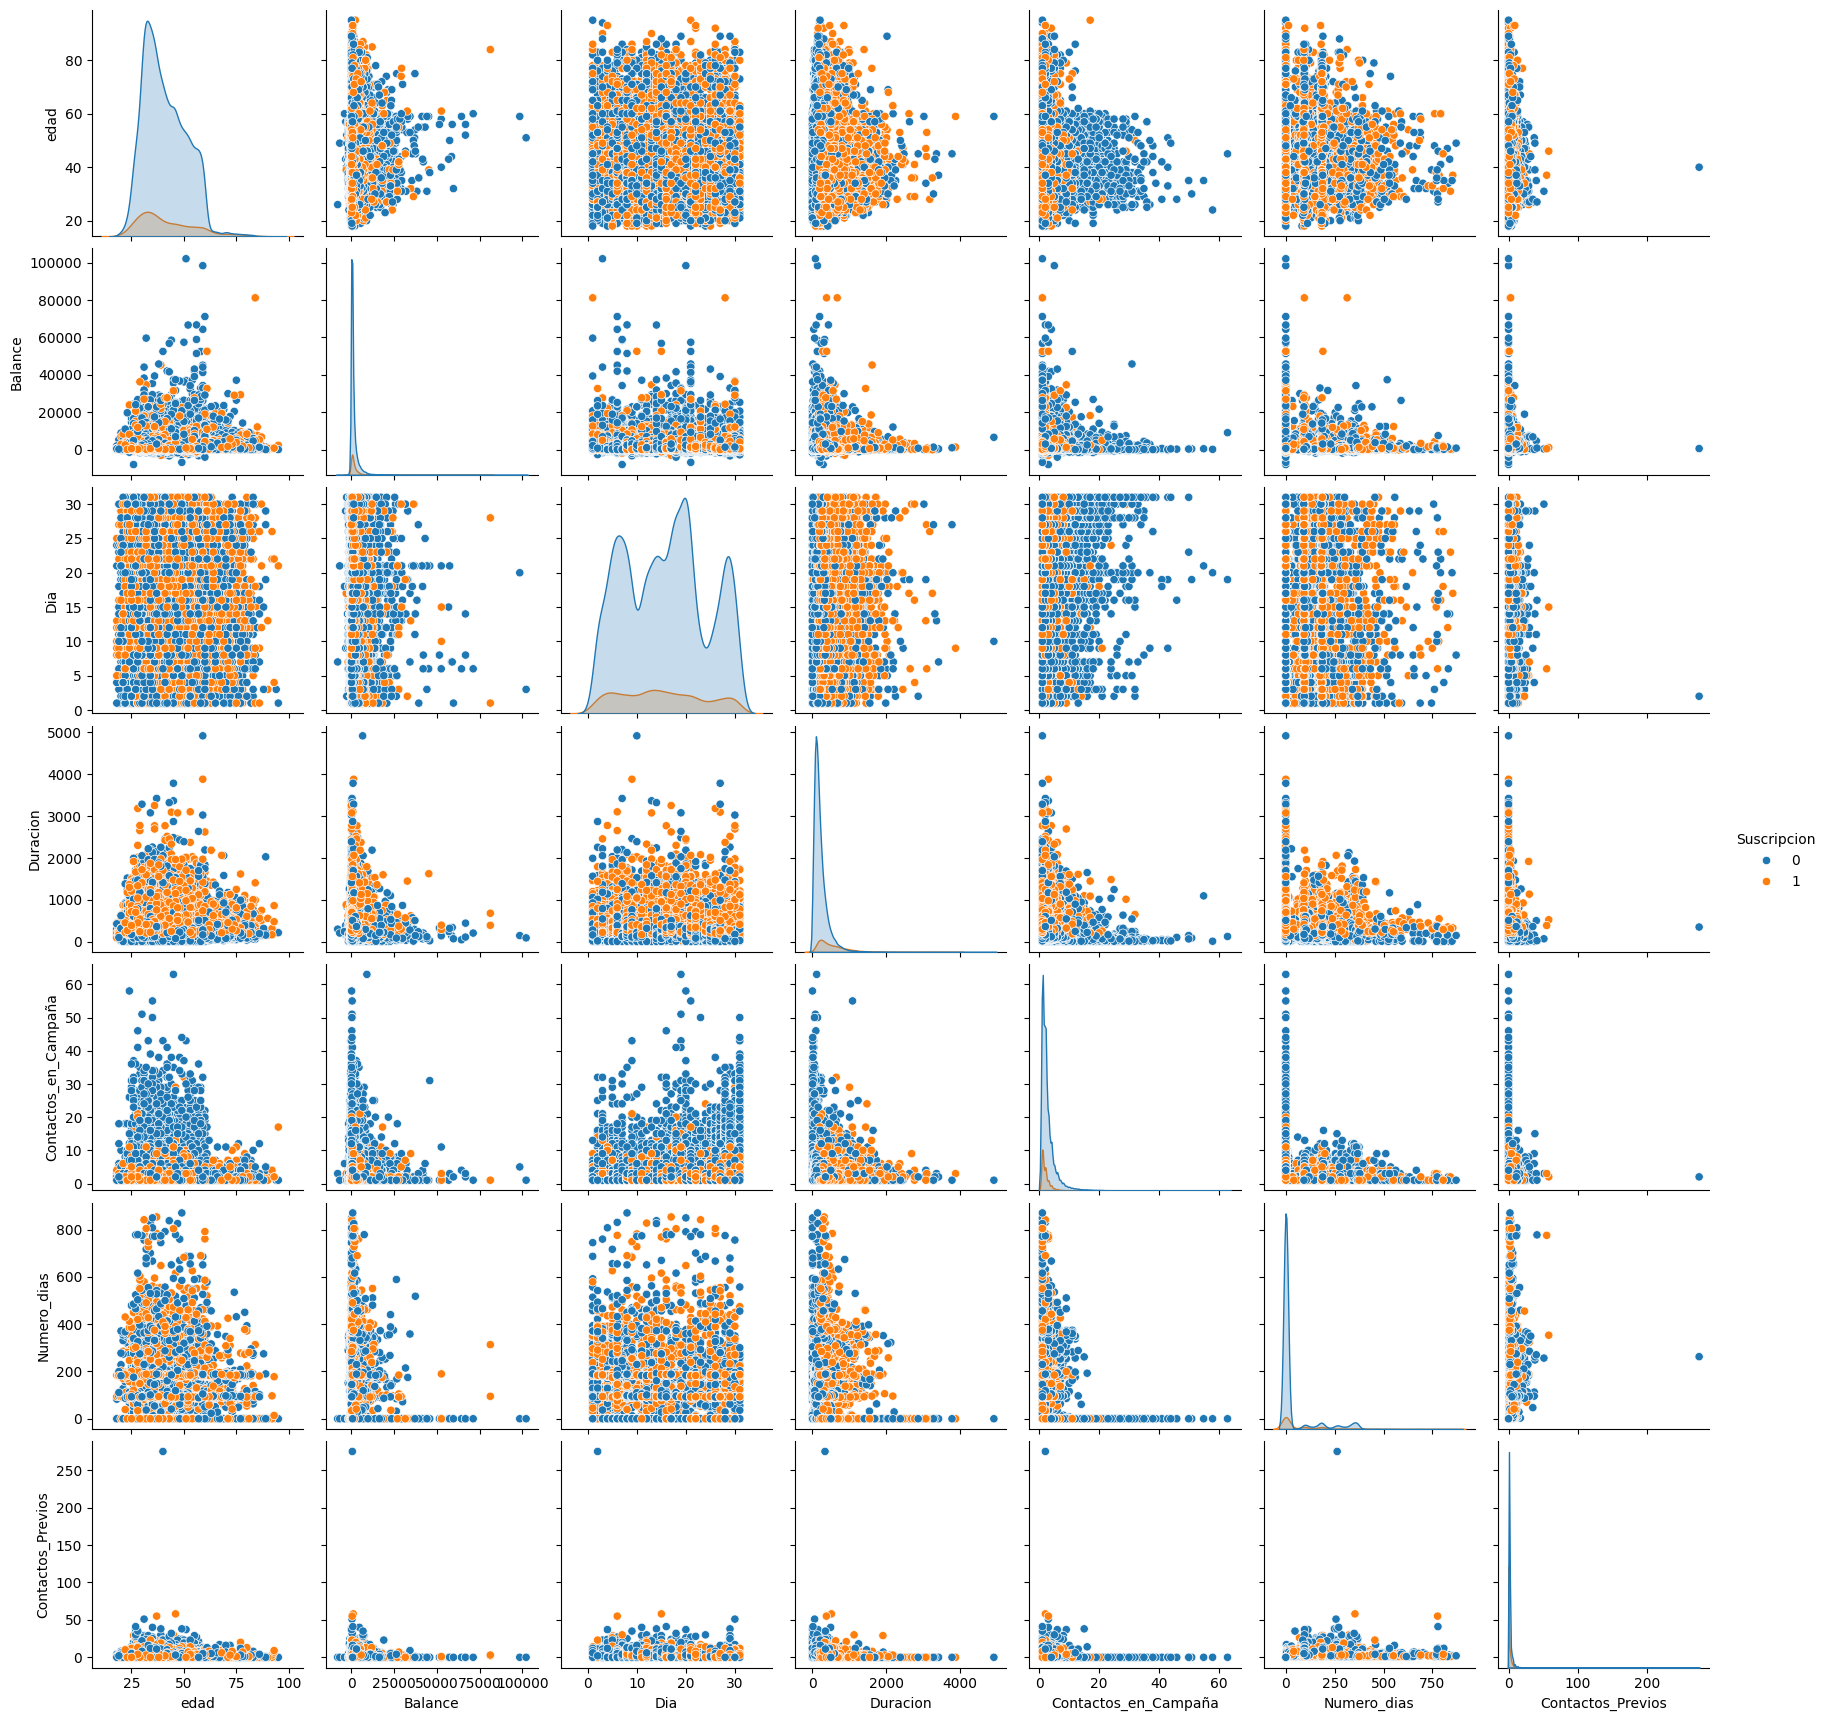

In [19]:
### Se requiere hacer un grafico 
sns.pairplot(dfauxNum.toPandas(), kind = 'scatter', hue='Suscripcion')
plt.show()

### El pairplot (matriz de dispersión) muestra simultáneamente:
   - Distribución individual de cada variable (KDE / histograma)
   - Coloración por clase: Azul = no suscribió, Naranja = sí suscribió

### Distribuciones individuales
   - El análisis de Numero_dias muestra que la gran mayoría de clientes se concentra en el valor 0 (nunca contactados previamente). Al cruzarlo con Duracion, se ve que los clientes que suscribieron tienden a combinar valores positivos de Numero_dias con llamadas más largas, lo que sugiere que haber sido contactado previamente y recibir una llamada extensa es un perfil favorable para la conversión
   - Contactos Previos, muestra una distribución muy comprimida alrededor de 0, con un outlier importante cercano a 275 contactos que probablemente corresponda a un error de registro y debería descartarse antes del modelado. En general esta variable no muestra separación visual entre clases en ninguno de sus pares
   - Duracion destaca como la variable con mayor poder  en todo el pairplot. Su KDE diagonal muestra claramente cómo la clase “no” se concentra en duraciones muy bajas con un pico pronunciado cerca de cero, mientras que la clase “yes” presenta una distribución más aplanada y desplazada hacia valores entre 500 y 1500 segundos. Esta separación se mantiene consistente en todos sus scatterplots contra las demás variables, independientemente de la edad, el balance o el día de contacto
   - Contactos en Campaña, muestra el patrón inverso, los puntos naranjas se agrupan entre 1 y 5 contactos, mientras que a partir de 10 o más contactos sobresalen casi únicamente los puntos azules, confirmando que insistir demasiado con la campaña reduce significativamente la probabilidad de conversión
   - Edad muestra una pequeña diferencia en su KDE, donde la clase “yes” tiene una presencia relativa algo mayor en edades por encima de los 55 años, coherente con el perfil de clientes jubilados identificado anteriormente
   - Balance presenta los outliers más extremos pertenecientes principalmente a la clase “no”, lo que confirma que el saldo bancario por sí solo no determina la decisión de suscripción
   - Día es la variable con menor utilidad, su distribución es bimodal, pero prácticamente idénticas entre clases, y ninguno de sus scatterplots muestra un patrón temporal asociado a la suscripción


# Gráfica de Torta  

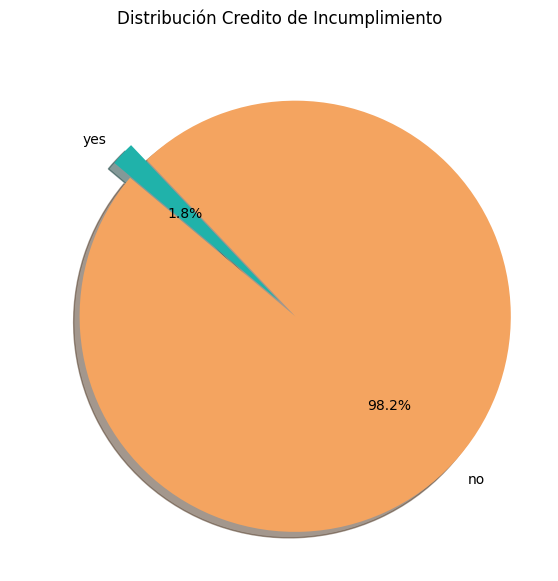

In [20]:
explode = (0.1,0)
colors =['sandybrown', 'lightseagreen']

plt.figure(figsize=(7, 7)) 
cantBin = df02.groupBy('Credito_Incumplimiento').count().toPandas() 

cantBin.set_index('Credito_Incumplimiento')['count'].plot(
    kind='pie', 
    explode=explode, 
    colors=colors, 
    autopct='%1.1f%%', 
    startangle=140,
    shadow=True
)

plt.title('Distribución Credito de Incumplimiento')
plt.ylabel('') 
plt.show()

### Distribución extremadamente desbalanceada:
  - "no": 98.2% de los clientes NO tienen créditos en incumplimiento
  - "yes": solo el 1.8% sí los tiene
  - Esta variable presenta el desbalance más severo de todas las analizadas


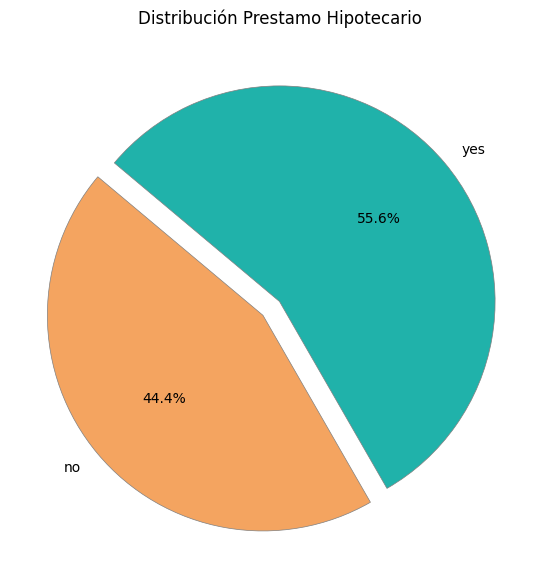

In [21]:
explode = (0.1,0)
colors =['sandybrown', 'lightseagreen']

plt.figure(figsize=(7, 7)) 
cantBin = df02.groupBy('Prestamo_Hipotecario').count().toPandas() 

cantBin.set_index('Prestamo_Hipotecario')['count'].plot(
    kind='pie', 
    explode=explode, 
    colors=colors, 
    autopct='%1.1f%%', 
    startangle=140,
    wedgeprops={'edgecolor': 'gray', 'linewidth': 0.5}
)

plt.title('Distribución Prestamo Hipotecario')
plt.ylabel('') 
plt.show()

### Distribución casi equilibrada entre las dos categorias:
   - "yes": 55.6% de los clientes tienen préstamo hipotecario
   - "no": 44.4% no lo tienen
   - Es la variable binaria con mejor balance de las tres analizadas.
   - Clientes con hipoteca activa podrían tener menor liquidez para nuevos productos.

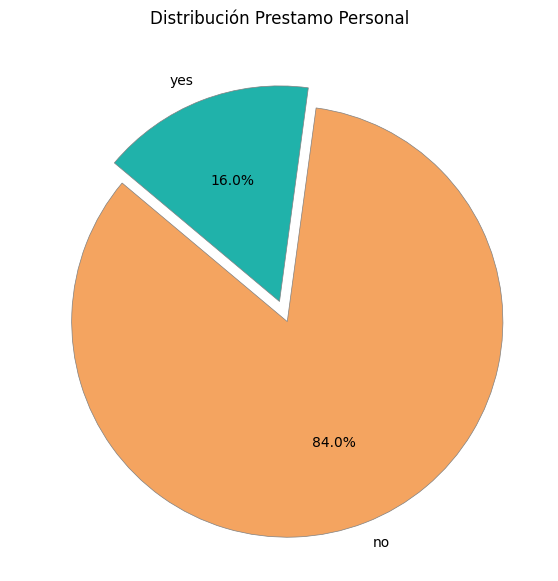

In [22]:
explode = (0.1,0)
colors =['sandybrown', 'lightseagreen']

plt.figure(figsize=(7, 7)) 
cantBin = df02.groupBy('Prestamo_Personal').count().toPandas() 

cantBin.set_index('Prestamo_Personal')['count'].plot(
    kind='pie', 
    explode=explode, 
    colors=colors, 
    autopct='%1.1f%%', 
    startangle=140,
    wedgeprops={'edgecolor': 'gray', 'linewidth': 0.5}
)


    
plt.title('Distribución Prestamo Personal')
plt.ylabel('') 
plt.show()

### Distribución desbalanceada:
   - "no": el 84.0% de los clientes no tienen préstamo personal
   - "yes": el 16.0% sí lo tienen
  - Aunque más balanceada que el Credito deIncumplimiento, sigue siendo asimétrica
  - Clientes con préstamos personales activos son menos probables a contratar productos adicionales por compromiso financiero existente


# Variables Categoricas Multidimensión 

- Estas gráficas de barras muestran la frecuencia absoluta de cada categoría dentro de las variables categóricas del dataset.
Permiten identificar:
   - Categorías dominantes que pueden sesgar el modelo
   - Categorías raras o con muy pocos registros
   - Valores "unknown" que requieren imputación o tratamiento especial

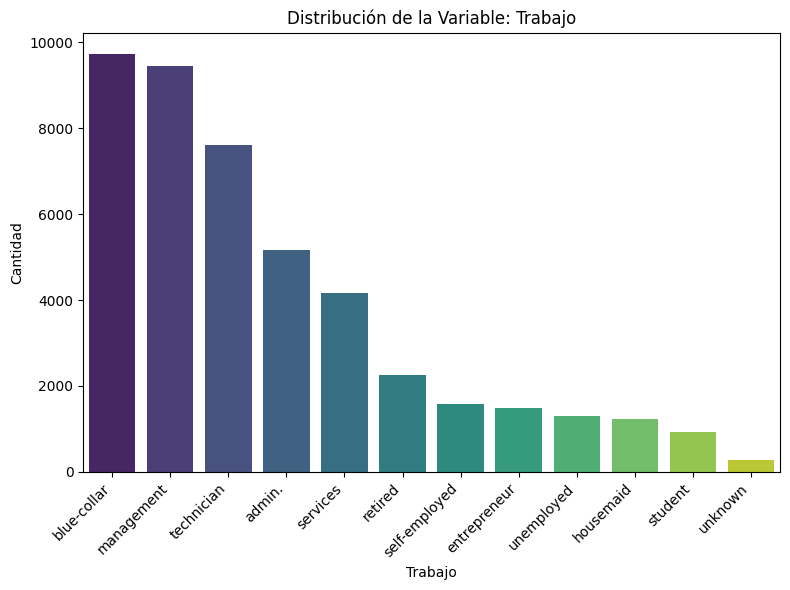

In [23]:
cantMulti = df02.groupBy('trabajo').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(
    data=cantMulti, 
    x='trabajo', 
    y='count', 
    palette='viridis',    
    hue='trabajo',
    legend=False         
)

plt.xlabel('Trabajo') 
plt.ylabel('Cantidad')
plt.title("Distribución de la Variable: Trabajo")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Comentarios
- Las tres categorías más frecuentes son:
   - blue-collar/trabajadores manuales ~9,800 registros
   - management/directivos ~9,700 registros
   - technician/técnicos ~7,700 registros
- Las menos frecuentes son "student" ~900 y "unknown" ~300.
- La categoría "unknown" debe tratarse: puede imputarse con la moda o codificarse como categoría independiente.
- Alta variedad de perfiles laborales


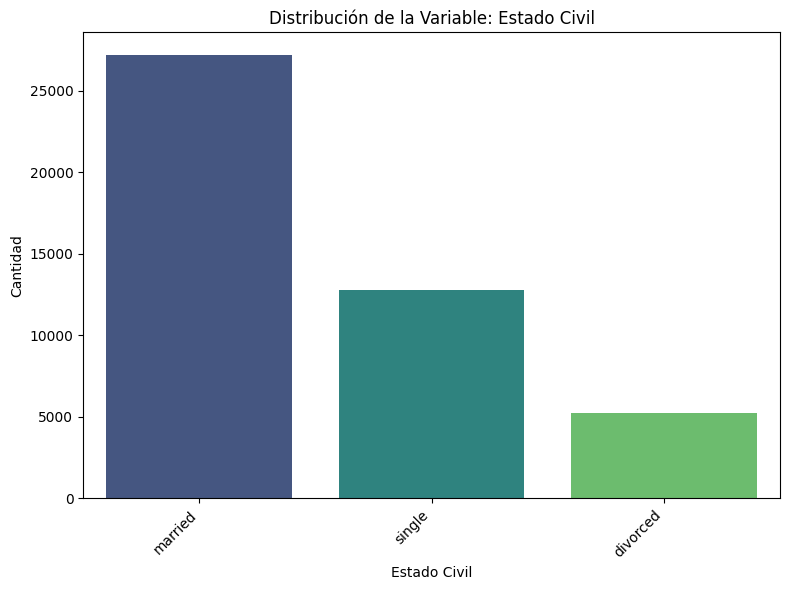

In [24]:
cantMulti = df02.groupBy('Estado_Civil').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(
    data=cantMulti, 
    x='Estado_Civil', 
    y='count', 
    palette='viridis',    
    hue='Estado_Civil',
    legend=False         
)

plt.xlabel('Estado Civil') 
plt.ylabel('Cantidad')
plt.title("Distribución de la Variable: Estado Civil")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


- Distribución claramente desbalanceada:
    - married/casados, ~27,000
    - single/solteros, ~13,000
    - divorced/divorciados ~5,300
- La predominancia de clientes casados puede introducir un sesgo hacia ese perfil en el modelo. Sin valores "unknown"
- Clientes solteros suelen tener mayor liquidez y podrían ser más receptivos a depósitos

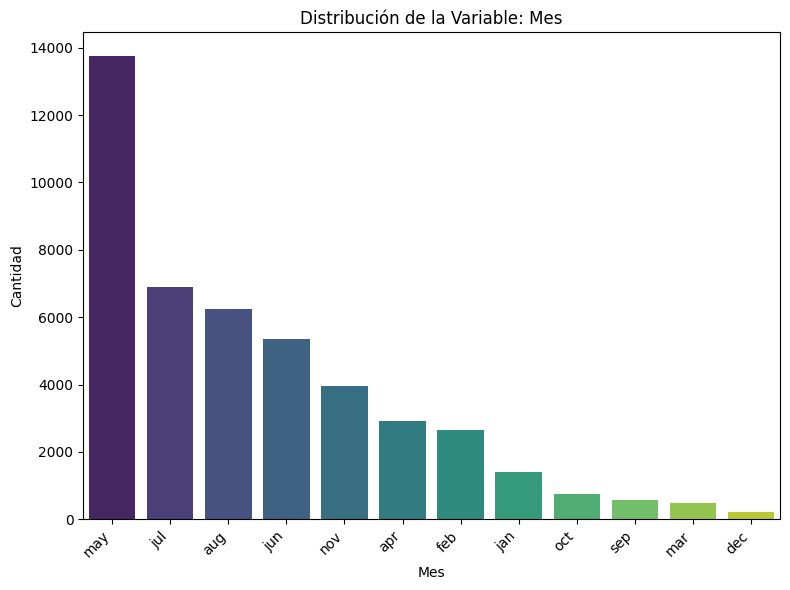

In [25]:
cantMulti = df02.groupBy('Mes').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(
    data=cantMulti, 
    x='Mes', 
    y='count', 
    palette='viridis',    
    hue='Mes',
    legend=False         
)

plt.xlabel('Mes') 
plt.ylabel('Cantidad')
plt.title("Distribución de la Variable: Mes")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


- Distribución muy desigual a lo largo del año:

    - mayo domina con ~14,000 contactos 
    - julio, agosto y junio son los siguientes meses más activos
    - diciembre tiene la menor actividad ~100 registros

- La concentración en mayo puede reflejar una estrategia comercial concentrada especificamente en este mes o simplemente el período de mayor actividad de la campaña
- Esta variable captura efectos estacionales relevantes para el modelo.
- Los meses con muy pocos datos son diciembre, marzo, septiembre y octubre

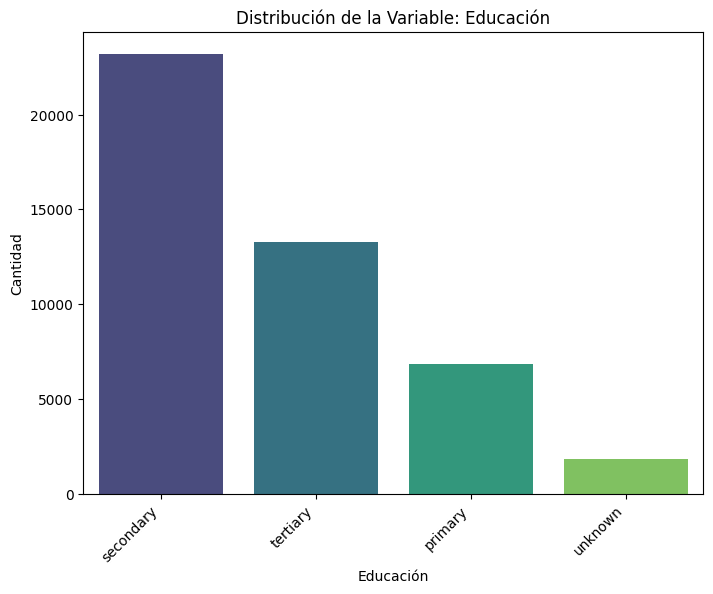

In [26]:
cantMulti = df02.groupBy('Educacion').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(
    data=cantMulti, 
    x='Educacion', 
    y='count', 
    palette='viridis',    
    hue='Educacion',
    legend=False         
)

plt.xlabel('Educación') 
plt.ylabel('Cantidad')
plt.title("Distribución de la Variable: Educación")
plt.xticks(rotation=45, ha='right')
plt.show()


- Cuatro niveles jerárquicos con distribución desbalanceada:
    - secondary, educación secundaria, mayoría del dataset (~23,000)
    - tertiary/educación universitaria (~13,000)
    - primary/educación básica (~6,700)
    - unknown, sin información registrada (~1,800) 

- La educación terciaria suele correlacionar con mayor ingreso y mayor propensión a productos de ahorro/inversión.
- "unknown" requiere imputación antes del modelado.

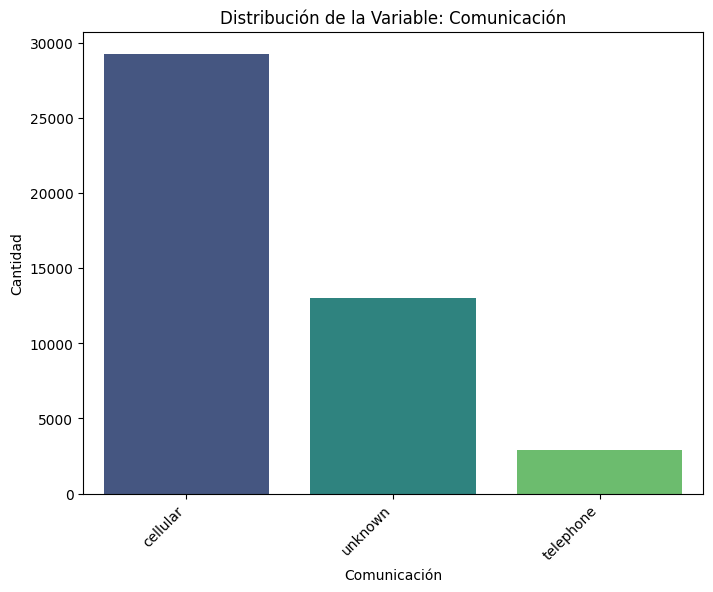

In [27]:
cantMulti = df02.groupBy('Comunicacion').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)

plt.figure(figsize=(8,6))

sns.barplot(
    data=cantMulti, 
    x='Comunicacion', 
    y='count', 
    palette='viridis',    
    hue='Comunicacion',     
    legend=False 
)

plt.xlabel('Comunicación')
plt.ylabel('Cantidad')
plt.title("Distribución de la Variable: Comunicación")
plt.xticks(rotation=45, ha='right') 

plt.show()


- Tres canales de contacto identificados:
    - cellular, canal que mas aparece (~29,000)
    - unknown/anal no registrado (~13,000)
    - telephone/teléfono fijo (~3,000)

- El alto porcentaje de "unknown" (~29%) demuestra que no se sabe si fueron contactados por celular o fijo, algo que es necesario revisar antes dle modelado
- El canal puede influir en la tasa de conversión, ya que contactos por celular suelen tener mayor tasa de respuesta


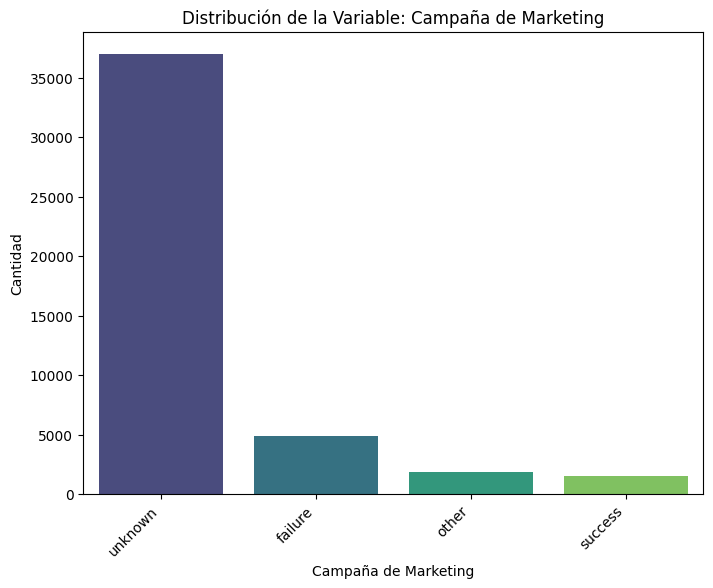

In [28]:
cantMulti = df02.groupBy('Campaña_Marketing').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(
    data=cantMulti, 
    x='Campaña_Marketing', 
    y='count', 
    palette='viridis',    
    hue='Campaña_Marketing',
    legend=False         
)

plt.xlabel('Campaña de Marketing') 
plt.ylabel('Cantidad')
plt.title("Distribución de la Variable: Campaña de Marketing")
plt.xticks(rotation=45, ha='right')
plt.show()


- Resultado de la campaña de marketing anterior:
    - unknown/sin campaña previa (~37,000)
    - failure/campaña anterior fallida (~4,900)
    - other/resultado no clasificado (~1,800) 
    - success/campaña anterior exitosa (~1,500)

- La alta presencia de valores en "unknown" se relaciona en como el numero de dias cuenta con valores agrupados entre -1 y 0 vistos en las graficas de las variables númericas
- La categoría "success" tiene muy pocos registros pero es la más informativa, clientes con éxito previo tienen mucha mayor probabilidad de suscribir en la campaña actual.

### Graficos de barras agrupados por variables categóricas en relación a la variable Suscripcion

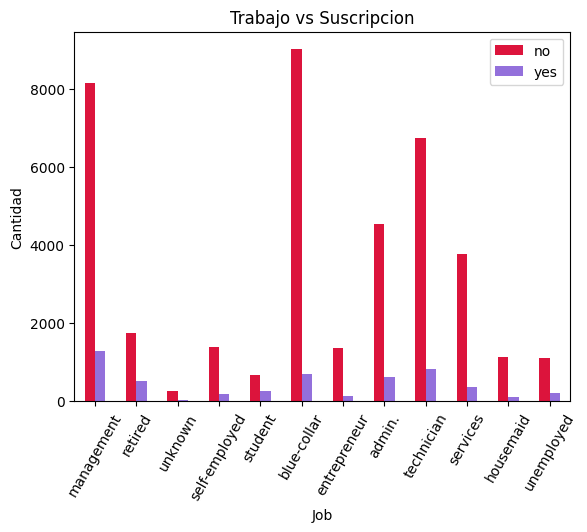

In [29]:
cratabJob = df02.crosstab('trabajo','Suscripcion').toPandas()

cratabJob.set_index('trabajo' + '_Suscripcion').plot(kind='bar', color=['crimson', 'mediumpurple'])

plt.xlabel('Job')
plt.ylabel('Cantidad')
plt.title('Trabajo vs Suscripcion')
plt.xticks(rotation=60)
plt.show()


- “blue-collar” es la categoría con mayor volumen de no suscriptores pero con una barra morada prácticamente invisible, lo que la hace el perfil con menor tasa de conversión de todo el gráfico
- también "management" y "technician" tienen volúmenes altos de suscriptores (~8,000 y ~6,700 respectivamente) pero sus barras moradas son un poco mas visibles
- "retired" y "student" son más destacables por su tasa de conversión, donde la barra morada, aunque de escaso volumen total, resulta proporcionalmente importante
- “unknown”, “housemaid” y “unemployed” presentan niveles muy bajos de frecuencia en ambas clases, por lo cual aportan poca representatividad al modelo


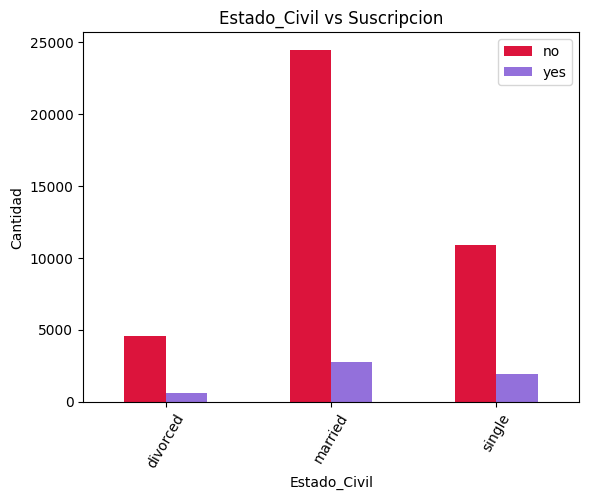

In [30]:
cratabJob = df01.crosstab('Estado_Civil','Suscripcion').toPandas()
cratabJob.set_index('Estado_Civil' + '_Suscripcion').plot(kind='bar', color=['crimson', 'mediumpurple'])
plt.xlabel('Estado_Civil')
plt.ylabel('Cantidad')
plt.title('Estado_Civil vs Suscripcion')
plt.xticks(rotation=60)
plt.show()

- Los clientes “married” conforman el grupo más grande, con unos 24.500 No suscriptores y alrededor de 2.900 suscriptores (10-11% de tasa de conversión, la más baja de los 3 grupos)
- Los solteros ("single") tienen una proporción morada visualmente más grande, con aproximadamente 2.000 suscriptores de un total de ~13.000 contactos
- Los divorciados (“divorced”), aunque son el grupo más pequeño con ~5,000 registros totales, tienen una barra morada proporcionalmente comparable a la de los solteros.
- En conclusión, el estado civil tiene un poder moderado de predicción, ya que, aunque la mayoría de los clientes están casados, estos son los menos propensos a suscribir, posiblemente por mayores compromisos financieros familiares, mientras que solteros y divorciados muestran mayor aceptación al producto.

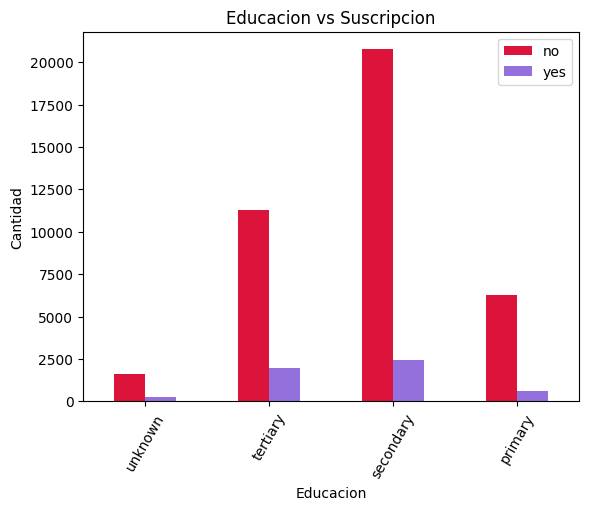

In [31]:
cratabJob = df01.crosstab('Educacion','Suscripcion').toPandas()
cratabJob.set_index('Educacion' + '_Suscripcion').plot(kind='bar', color=['crimson', 'mediumpurple'])
plt.xlabel('Educacion')
plt.ylabel('Cantidad')
plt.title('Educacion vs Suscripcion')
plt.xticks(rotation=60)
plt.show()

- La educación muestra un patrón interesante al analizar las proporciones internas de cada categoría
- "secondary" (secundaria) concentra el mayor volumen absoluto con ~20,500 no suscriptores y ~2,500 suscriptores
- "tertiary" (universitarios) presenta una relación más favorable con ~11,500 no suscriptores frente a ~2,000 suscriptores, siendo el nivel educativo con mejor conversión relativa
- "primary"(primaria) tiene la tasa más baja con apenas ~600 suscriptores sobre ~7,000 contactos totales, lo que sugiere que a menor nivel educativo menor receptividad al producto
- "unknown" (desconocido) tiene muy pocos registros en ambas clases y no aporta información relevante
- En conclusión, existe una relación positiva entre nivel educativo y tasa de conversión: a mayor formación académica, mayor propensión a suscribir el depósito, lo que cobra sentido considerando que los clientes con educación universitaria comprenden y valoran mejor los productos de ahorro e inversión.

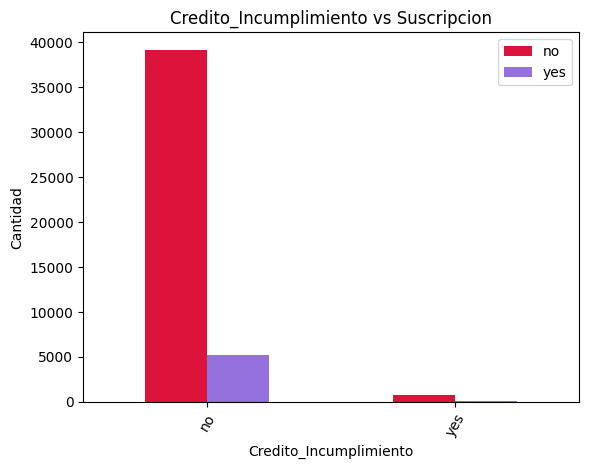

In [32]:
cratabJob = df01.crosstab('Credito_Incumplimiento','Suscripcion').toPandas()
cratabJob.set_index('Credito_Incumplimiento' + '_Suscripcion').plot(kind='bar', color=['crimson', 'mediumpurple'])
plt.xlabel('Credito_Incumplimiento')
plt.ylabel('Cantidad')
plt.title('Credito_Incumplimiento vs Suscripcion')
plt.xticks(rotation=60)
plt.show()

- El mayor número de registros son clientes sin incumplimiento crediticio, donde se puede apreciar el número de personas que si se suscribieron es visible con aproximadamente 5 mil suscripciones dentro de este grupo
- En contraste, los clientes con credito de incumplimiento ( “yes”) prácticamente no tienen suscripciones, ya que la barra roja es prácticamente imperceptible
- Esto confirma lo que ya se había visto, el hecho de tener un crédito en mora hace desaparecer casi totalmente la probabilidad de suscribir un depósito
- En conclusión, si bien se trata de una variable de escaso poder predictivo debido al extremo desbalance, sí que resulta útil como un filtro para detectar clientes de alto riesgo

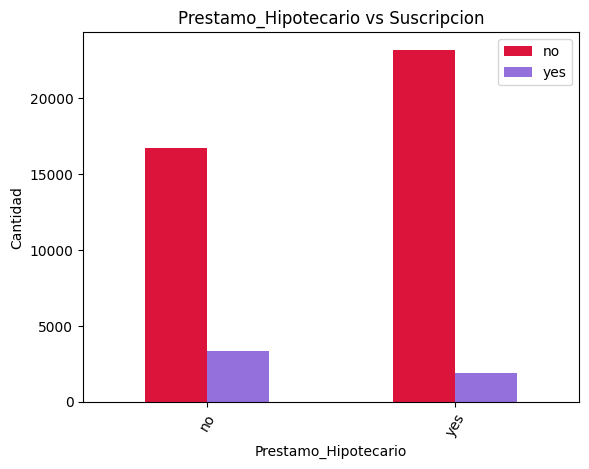

In [33]:
cratabJob = df01.crosstab('Prestamo_Hipotecario','Suscripcion').toPandas()
cratabJob.set_index('Prestamo_Hipotecario' + '_Suscripcion').plot(kind='bar', color=['crimson', 'mediumpurple'])
plt.xlabel('Prestamo_Hipotecario')
plt.ylabel('Cantidad')
plt.title('Prestamo_Hipotecario vs Suscripcion')
plt.xticks(rotation=60)
plt.show()

- El gráfico muestra la relación entre tener un préstamo hipotecario activo o no y la decisión de contratar el depósito a plazo. En los dos grupos la barra roja (“no suscribió”) domina ampliamente sobre la morada (“sí suscribió”), lo cual es consistente con el desbalance global del dataset ya identificado
Lo más relevante está en las proporciones internas de cada grupo: entre los clientes sin hipoteca ("no") la barra morada es proporcionalmente más visible
- Pero entre los clientes que tienen hipoteca (“yes”), la barra morada se reduce significativamente, con sólo alrededor de 1.900 suscripciones.

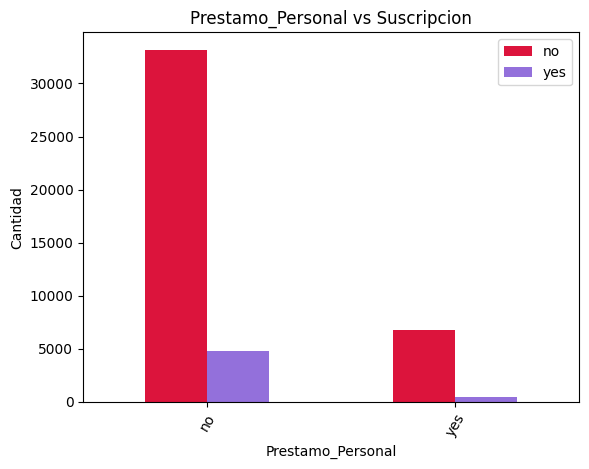

In [34]:
cratabJob = df01.crosstab('Prestamo_Personal','Suscripcion').toPandas()
cratabJob.set_index('Prestamo_Personal' + '_Suscripcion').plot(kind='bar', color=['crimson', 'mediumpurple'])
plt.xlabel('Prestamo_Personal')
plt.ylabel('Cantidad')
plt.title('Prestamo_Personal vs Suscripcion')
plt.xticks(rotation=60)
plt.show()

- Entre los clientes sin préstamo personal (“no”), la barra roja alcanza alrededor de 33 mil registros que no suscribieron, mientras que la barra morada muestra cerca de 5 mil que sí lo hicieron, lo que representa una tasa de conversión de aproximadamente 13%
- Por el contrario, entre los clientes con préstamo personal activo (“yes”), la barra roja cae a unos 7,000 no suscriptores y la morada se reduce drásticamente a menos de 500 suscripciones
- El patrón demuestra que tener un préstamo personal activo reduce a la mitad la probabilidad de suscribir el depósito, lo que refuerza la idea de que el nivel de endeudamiento del cliente es un factor  relevante para la conversión

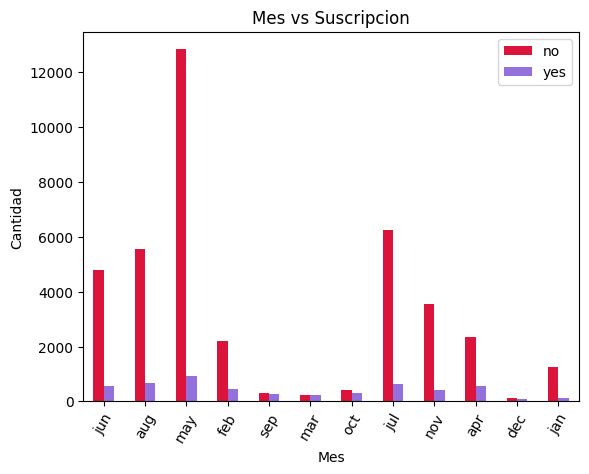

In [35]:
cratabJob = df01.crosstab('Mes','Suscripcion').toPandas()
cratabJob.set_index('Mes' + '_Suscripcion').plot(kind='bar', color=['crimson', 'mediumpurple'])
plt.xlabel('Mes')
plt.ylabel('Cantidad')
plt.title('Mes vs Suscripcion')
plt.xticks(rotation=60)
plt.show()

- La gráfica confirma la confusión ya identificada entre volumen de campaña y % de tasa de conversión. Mayo domina en volumen con más de 13 mil contactos en rojo pero apenas ~1 mil en morado, resultando en una de las tasas más bajas del año. Julio muestra un patrón similar, con ~ 6.200 no suscriptores contra ~ 600 suscriptores
- En cambio, meses con muy poca actividad como diciembre muestran barras rojas apenas visibles pero con una proporción morada relativamente alta, y octubre y septiembre también tienen tasas de conversión visualmente superiores a la media
- Se confirma que los meses de menor intensidad de campaña generan contactos más calificados y por lo tanto mayor efectividad, mientras que los meses de alta actividad masiva reducen la calidad de los clientes contactados

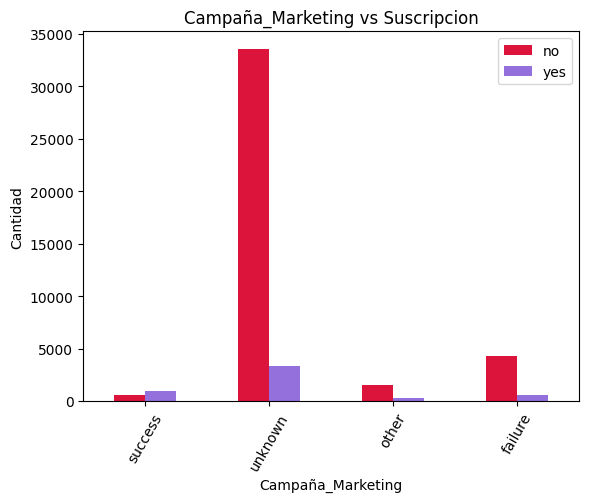

In [36]:
cratabJob = df01.crosstab('Campaña_Marketing','Suscripcion').toPandas()
cratabJob.set_index('Campaña_Marketing' + '_Suscripcion').plot(kind='bar', color=['crimson', 'mediumpurple'])
plt.xlabel('Campaña_Marketing')
plt.ylabel('Cantidad')
plt.title('Campaña_Marketing vs Suscripcion')
plt.xticks(rotation=60)
plt.show()

- Esta gráfica confirma que el resultado de la campaña anterior es el predictor categórico más útil de todo el dataset
- En la categoría "success", es el único caso en el análisis completo donde los suscriptores son más numerosos que los no suscriptores
- En “unknown” la barra roja es masiva (~33.500) frente a una morada modesta (~3.500), reflejando la baja tasa de conversión base
- "failure" muestra muy pocas conversiones con ~4,500 no suscriptores, mientras que "other" tiene proporciones similares pero con volúmenes menores
- En conclusión, un cliente que haya respondido positivamente a una campaña anterior tiene más del doble de probabilidad de suscribir que el promedio general, por lo que esta variable se convierte en un criterio de clasificación prioritario para próximas campañas

# Tasa de conversión por edad agrupada

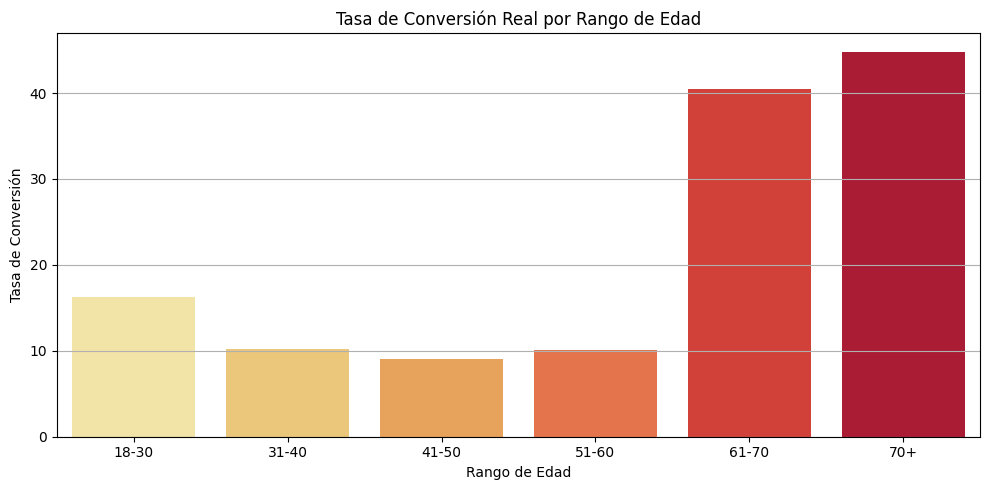

In [37]:
# 1. Se agrupa la edad en rangos de 10 años
dfEdad = df02.toPandas()
dfEdad['Rango_Edad'] = pd.cut(dfEdad['edad'], 
                              bins=[17, 30, 40, 50, 60, 70, 100], 
                              labels=['18-30', '31-40', '41-50', '51-60', '61-70', '70+'])

# CORRECCIÓN 1: Se añade observed=False para mantener el comportamiento actual de groupby
tasaEdad = dfEdad.groupby('Rango_Edad', observed=False)['Suscripcion'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).reset_index()

tasaEdad.columns = ['Rango_Edad', 'Tasa_Conversion']

plt.figure(figsize=(10, 5))

# CORRECCIÓN 2: Se asigna 'Rango_Edad' a hue y se desactiva la leyenda
sns.barplot(data=tasaEdad, x='Rango_Edad', y='Tasa_Conversion', hue='Rango_Edad', palette='YlOrRd', legend=False)

plt.title('Tasa de Conversión Real por Rango de Edad')
plt.xlabel('Rango de Edad')
plt.ylabel('Tasa de Conversión')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


# Comentarios generales
- La gráfica muestra que los rangos intermedios de edad, 31-40, 41-50 y 51-60 años son los que presentan las tasas de conversión más bajas de todo el conjunto de datos, todas por debajo del 11%, lo que confirma que la población activa en la plena etapa laboral y de mayor endeudamiento (hipotecas, préstamos personales, gastos familiares) es la menos receptiva a contratar un depósito a plazo
- El rango 18-30 muestra una tasa ligeramente superior (~16%), coherente con el hallazgo anterior sobre los estudiantes: jóvenes sin cargas financieras significativas con mayor apertura a nuevos productos bancarios
- Los clientes de 61-70 años alcanzan una tasa de conversión del 40,6% y los mayores de 70 años llegan al 45%, siendo este último grupo el de mayor propensión a suscribir de todo el dataset
- Eso tiene una explicación de negocio: las personas en etapa de retiro o prejubilación han saldado sus deudas principales, tienen ahorros acumulados y están buscando activamente productos financieros seguros que les generen rendimiento sin riesgo, el depósito a plazo es exactamente ese tipo de producto
- El resultado encontrado confirma lo detectado en los boxplots y demuestra que la edad es un predictor relevante cuando se analiza por rangos


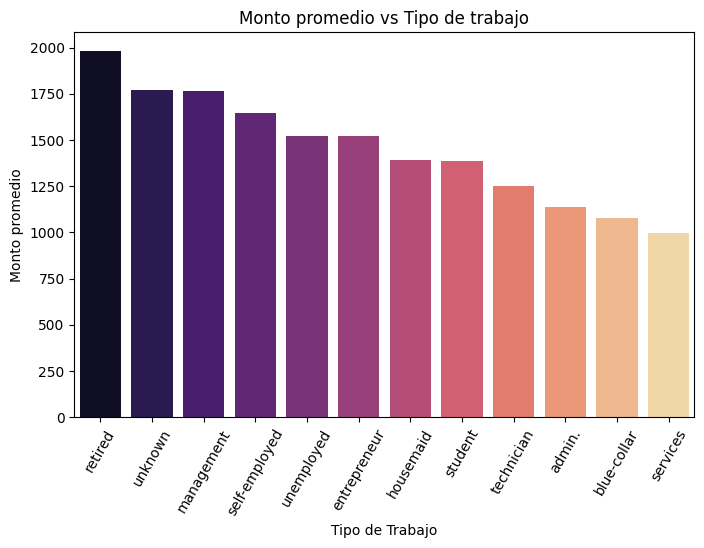

In [38]:
NomColumnas = ['edad',
 'trabajo',
 'Estado_Civil',
 'Educacion',
 'Credito_Incumplimiento',
 'Balance',
 'Prestamo_Hipotecario',
 'Prestamo_Personal',
 'Comunicacion',
 'Dia',
 'Mes',
 'Duracion',
 'Contactos_en_Campaña',
 'Numero_dias',
 'Contactos_Previos',
 'Campaña_Marketing',
 'Suscripcion']

colNum = ['edad', 'Balance', 'Dia', 'Duracion', 'Campaña_Marketing', 'Numero_dias', 'Contactos_previos']
monto = df01.groupBy('trabajo').agg({'Balance':'mean'}).toPandas()
monto = monto.sort_values('avg(Balance)',ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=monto, x='trabajo', y='avg(Balance)',palette='magma',hue='trabajo', legend=False)
plt.xlabel('Tipo de Trabajo')
plt.ylabel('Monto promedio')
plt.title('Monto promedio vs Tipo de trabajo')
plt.xticks(rotation=60)
plt.show()

# Conclusiones Principales
- Las personas retiradas (jubiladas) encabezan el gráfico con la mayor cantidad promedio, cerca de los 2,000 unidades
- El promedio más bajo de la distribución lo tiene el sector de servicios (services) justo en las 1,000 unidades
- Los profiles de management y el category unknown siguen inmediatamente a los retirados, con promedios muy similares entre sí (cercanos a 1,750)
- Hay un gasto o monto estable en los empleados independientes/asociados (employed), emprendedores (entrepreneur), empleados domésticos (housemaid) y estudiantes (student), que están en un rango medio de 1.400 a 1.500 unidades
- Los roles operativos o técnicos (technician, admin, blue-collar) muestran una disminución progresiva del monto promedio a medida que avanzamos hacia la derecha de la gráfica.

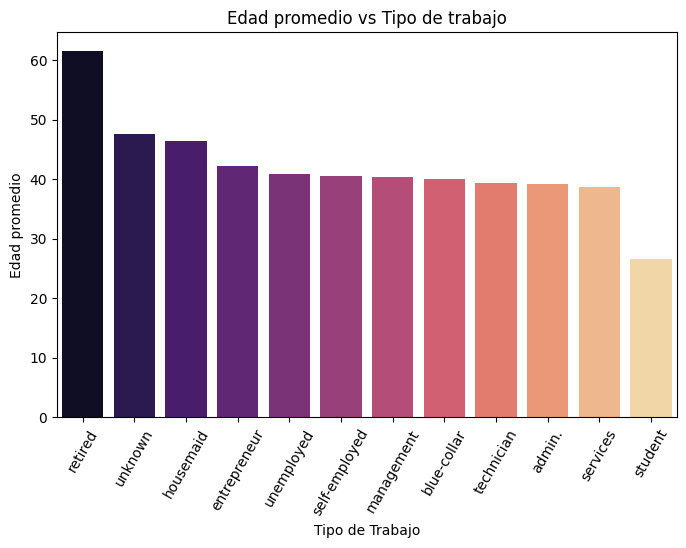

In [39]:
monto = df01.groupBy('trabajo').agg({'edad':'mean'}).toPandas()
monto = monto.sort_values('avg(edad)',ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=monto, x='trabajo', y='avg(edad)', palette='magma',hue='trabajo', legend=False)
plt.xlabel('Tipo de Trabajo')
plt.ylabel('Edad promedio')
plt.title('Edad promedio vs Tipo de trabajo')
plt.xticks(rotation=60)
plt.show()

# Conclusiones Principales
- Los jubilados o retirados (retired) son el grupo de mayor edad promedio, superando ampliamente los 60 años
- Los estudiantes (student) son el grupo más joven con una edad promedio muy baja, de alrededor de 25 años
- Las categorías unknown (desconocido) y housemaid (empleados domésticos) se encuentran en el segundo bloque con mayor edad, con promedios entre 45 y 48 años
- En la clase media de la gráfica hay mucha estabilidad demográfica, ya que los emprendedores, desempleados, trabajadores independientes, administrativos y técnicos (entrepreneur, unemployed, self-employed, management, blue-collar, technician, admin, services) tienen una edad promedio muy parecida, y se mantienen firmes entre los 38 y los 42 años

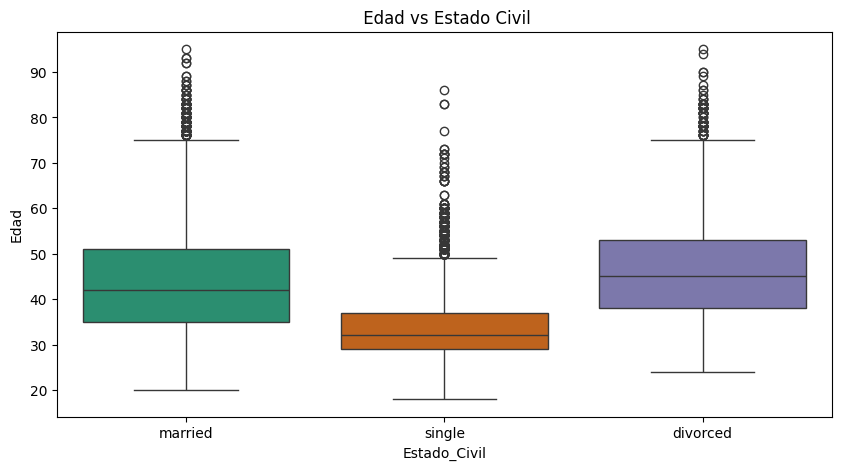

In [40]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Estado_Civil', y='edad', data=df02.toPandas(), hue='Estado_Civil', palette='Dark2', legend=False)
plt.title(f" Edad vs Estado Civil")
plt.xlabel("Estado_Civil")
plt.ylabel('Edad')
plt.show()

# Conclusiones Principales
- Los solteros (single) son los más jóvenes de todo el estudio, con una edad media cercana a los 32 años. Su rango intercuartílico (caja azul) es el más estrecho, con la gran mayoría concentrada entre los aproximadamente 29 y 37 años
- Los divorciados tienen la mediana de edad más alta (alrededor de los 45 años), seguidos muy de cerca por los casados, cuya mediana ronda los 42 años
-  Los grupos de casados y de divorciados presentan una dispersión y cajas muy similares, compartiendo casi el mismo rango de edad para el 50% central de sus poblaciones (aproximadamente entre los 35 y los 52 años).
- Los tres estados civiles, en la parte superior, presentan una cantidad considerable de puntos aislados. Esto hace suponer la existencia de usuarios con edades poco comunes (desde los 75 hasta los 90 y más) que rompen la tendencia normal de cada grupo, siendo especialmente notorio en el grupo de solteros donde cualquier persona mayor de 50 años ya es un caso atípico

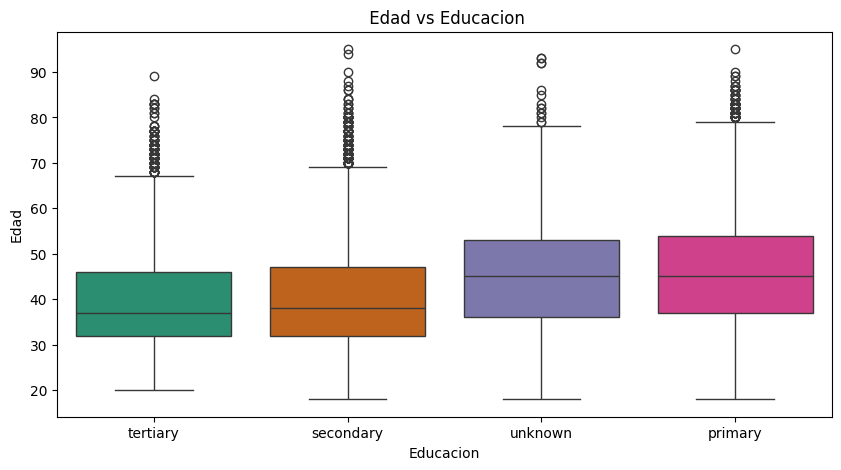

In [41]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Educacion', y='edad', data=df02.toPandas(), hue='Educacion', palette='Dark2', legend=False)
plt.title(f" Edad vs Educacion")
plt.xlabel("Educacion")
plt.ylabel('Edad')
plt.show()

# Conclusiones Principales
- El boxplot revela una relación clara entre el nivel educativo y la edad de los clientes. Los grupos con educación "tertiary" (universitaria) y "secondary" presentan las medianas más bajas, ambas alrededor de los 37-38 años, con cajas comprimidas entre los 30 y 45 años aproximadamente, indicando que son niveles educativos predominantemente asociados a población joven y de mediana edad. 
- Los grupos "unknown" y "primary" tienen medianas más altas cercanas a los 45 años y cajas que se extienden hasta los 53-54 años, lo que refleja que los clientes de mayor edad tienden a tener menor nivel educativo formal, algo coherente con el contexto generacional donde el acceso a educación superior era más limitado décadas atrás
- Los outliers por encima de los 80-90 años están presentes en todos los grupos, pero son especialmente numerosos en "tertiary" y "secondary", posiblemente porque estos grupos tienen una mayor cantidad de registros
- Esta relación inversa entre edad y nivel educativo es un hallazgo confirma que estas dos variables están correlacionadas y deben interpretarse en conjunto al analizar perfiles de clientes.

# Calidad de los Datos:

In [42]:
# Se itera sobre todas las columnas del DataFrame df02 para contar cuántos valores nulos tiene cada una
# los algoritmos de Spark MLlib no toleran valores nulos en las columnas de entrada
for columna in df02.columns:
    cantNulos = df02.where(F.col(columna).isNull()).count()
    print(f"{columna}' : {cantNulos} valores nulos")

edad' : 0 valores nulos
trabajo' : 0 valores nulos
Estado_Civil' : 0 valores nulos
Educacion' : 0 valores nulos
Credito_Incumplimiento' : 0 valores nulos
Balance' : 0 valores nulos
Prestamo_Hipotecario' : 0 valores nulos
Prestamo_Personal' : 0 valores nulos
Comunicacion' : 0 valores nulos
Dia' : 0 valores nulos
Mes' : 0 valores nulos
Duracion' : 0 valores nulos
Contactos_en_Campaña' : 0 valores nulos
Numero_dias' : 0 valores nulos
Contactos_Previos' : 0 valores nulos
Campaña_Marketing' : 0 valores nulos
Suscripcion' : 0 valores nulos


# Preparación de los datos

In [43]:
# Se cuenta cuántos clientes tienen el valor -1 en Numero_dias, indica que nunca fueron contactados en campañas anteriores
noPDAYS = df02.filter(F.col('Numero_dias') == -1).count()
porcNoPDAYS = (noPDAYS/total)*100
print(f"Porcentaje de cliuentes no contactados con anterioridad (variable PDAYS = -1): {porcNoPDAYS:.2f}%")

Porcentaje de cliuentes no contactados con anterioridad (variable PDAYS = -1): 81.74%


In [44]:
# Se ordenan los valores de mayor a menor para identificar outliers extremos que puedan afectar negativamente el modelo
df02.groupBy("Contactos_Previos").count().sort("Contactos_Previos", ascending=False).show()

+-----------------+-----+
|Contactos_Previos|count|
+-----------------+-----+
|              275|    1|
|               58|    1|
|               55|    1|
|               51|    1|
|               41|    1|
|               40|    1|
|               38|    2|
|               37|    2|
|               35|    1|
|               32|    1|
|               30|    3|
|               29|    4|
|               28|    2|
|               27|    5|
|               26|    2|
|               25|    4|
|               24|    5|
|               23|    8|
|               22|    6|
|               21|    4|
+-----------------+-----+
only showing top 20 rows



In [45]:
# Se define un límite máximo de 30 contactos previos como umbral
# Valores superiores son considerados outliers o errores de registro

limitePrevio = 30
cantPrevioLim = df02.filter(F.col('Contactos_Previos') > limitePrevio).count()

print(f"Cantidad de registros superiores a {limitePrevio} contactos realizados: {cantPrevioLim}")

Cantidad de registros superiores a 30 contactos realizados: 12


# Limpieza

In [46]:
# Se elimina del dataset todo registro con más de 30 contactos previos
df03 = df02.filter(F.col('Contactos_Previos') <=30)

In [47]:
# Se elimina la columna del numero de dias del dataset
df04 = df03.drop('Numero_dias')

# Formato de Datos

In [48]:
# Se separa el dataset en dos grupos según la variable objetivo:
# dfMayorD: clase mayoritaria ("no" = no suscribió)
# dfMenorD: clase minoritaria ("yes" = sí suscribió)

dfMayorD = df04.filter(df04['Suscripcion'] == 'no')
dfMenorD = df04.filter(df04['Suscripcion'] == 'yes')

# Se aplica OVERSAMPLING sobre la clase minoritaria
cantMayor = dfMayorD.count()
dfOverSampleM = dfMenorD.sample(True, cantMayor/dfMenorD.count(), seed=42) # suficientes muestras de "yes" hasta igualar el tamaño de "no"

# Se une la clase mayoritaria original con la clase minoritaria oversampleada
# el dataset terminara balanceado con aproximadamente 50% de cada clase
df05 = dfMayorD.union(dfOverSampleM)

In [49]:
df05.columns

['edad',
 'trabajo',
 'Estado_Civil',
 'Educacion',
 'Credito_Incumplimiento',
 'Balance',
 'Prestamo_Hipotecario',
 'Prestamo_Personal',
 'Comunicacion',
 'Dia',
 'Mes',
 'Duracion',
 'Contactos_en_Campaña',
 'Contactos_Previos',
 'Campaña_Marketing',
 'Suscripcion']

In [50]:
# Verificación del balance resultante 
totalNw = df05.count()
dfaux = df05.groupBy('Suscripcion').count()
dfBalance = dfaux.withColumn("Porcentaje", dfaux["count"]*100/totalNw)
dfBalance.show()

+-----------+-----+-----------------+
|Suscripcion|count|       Porcentaje|
+-----------+-----+-----------------+
|         no|39912|49.76496552412065|
|        yes|40289|50.23503447587935|
+-----------+-----+-----------------+



In [51]:
# Comparación de tamaño entre dataset original y dataset balanceado
print(f"Cantidad de registros de DF01 = {df01.count()}")
print(f"Cantidad de registros de DF05 = {df05.count()}")

Cantidad de registros de DF01 = 45211
Cantidad de registros de DF05 = 80201


- df05 es mucho más grande que df01 debido a la replicación de registros de la clase minoritaria

In [52]:
df05.columns

['edad',
 'trabajo',
 'Estado_Civil',
 'Educacion',
 'Credito_Incumplimiento',
 'Balance',
 'Prestamo_Hipotecario',
 'Prestamo_Personal',
 'Comunicacion',
 'Dia',
 'Mes',
 'Duracion',
 'Contactos_en_Campaña',
 'Contactos_Previos',
 'Campaña_Marketing',
 'Suscripcion']

In [53]:
CATEG_col = ['trabajo', 'Estado_Civil','Educacion', 'Credito_Incumplimiento', 'Prestamo_Hipotecario',
           'Prestamo_Personal', 'Comunicacion','Mes', 'Campaña_Marketing']
etapas = [] # Lista vacía que acumulará todas las etapas del Pipeline

# Para cada variable categórica se aplica una secuencia de dos transformaciones:
#   1. StringIndexer: convierte las categorías de texto a índices numéricos
#   2. OneHotEncoder: convierte el índice numérico a un vector binario disperso
# Esto es usado para evitar que el modelo interpreteclas categorías como valores ordinales con jerarquía numérica

for colCategoria in CATEG_col:
    indexer = StringIndexer(inputCol=colCategoria, outputCol = colCategoria + 'x') # Columna intermedia indexada
    encoder = OneHotEncoder(inputCols = [indexer.getOutputCol()], outputCols=[colCategoria + '_oneHot']) # Columna final codificada
    etapas += [indexer, encoder]  # Se agregan ambas etapas a la lista 

In [54]:
etapas   # Visualización de todas las etapas acumuladas

[StringIndexer_3ee530f4c25a,
 OneHotEncoder_2b48b4dbe29c,
 StringIndexer_c246acb9136e,
 OneHotEncoder_2ae9302702c4,
 StringIndexer_f97690ea2b39,
 OneHotEncoder_de27b94ef174,
 StringIndexer_aa31a3d97f41,
 OneHotEncoder_e43d63d95b84,
 StringIndexer_3f093e0f59ad,
 OneHotEncoder_7af3d3b70b7e,
 StringIndexer_21a33e0b4e2f,
 OneHotEncoder_096a9ef783e8,
 StringIndexer_fe9f4e795811,
 OneHotEncoder_a0fee2d42ea5,
 StringIndexer_31b12e20b466,
 OneHotEncoder_a37d09c33b93,
 StringIndexer_0e1b45ae415d,
 OneHotEncoder_090370169924]

In [55]:
# StringIndexer sobre la variable dependiente 'Suscripcion' con orden alfabético ascendente:
# "no"=0, "yes"=1
# Se usa para que el modelo necesita la etiqueta como número (0/1)

etiqueta = StringIndexer(inputCol= 'Suscripcion', outputCol='label', stringOrderType='alphabetAsc')
etapas += [etiqueta]

In [56]:
# Lista de variables numéricas a incluir en el vector de features
NUMER = ['edad', 'Balance','Dia', 'Duracion','Contactos_en_Campaña','Contactos_Previos']

# Se construye la lista completa de columnas del vector de features
# variables categóricas codificadas (OneHot) + variables numéricas
Ensamblada = [c + '_oneHot' for c in CATEG_col] + NUMER
Ensamblada

['trabajo_oneHot',
 'Estado_Civil_oneHot',
 'Educacion_oneHot',
 'Credito_Incumplimiento_oneHot',
 'Prestamo_Hipotecario_oneHot',
 'Prestamo_Personal_oneHot',
 'Comunicacion_oneHot',
 'Mes_oneHot',
 'Campaña_Marketing_oneHot',
 'edad',
 'Balance',
 'Dia',
 'Duracion',
 'Contactos_en_Campaña',
 'Contactos_Previos']

In [57]:
# VectorAssembler combina todas las columnas de 'Ensamblada' en un único vector llamado 'features'
# Es el formato requerido por todos los algoritmos de Spark MLlib
VectorEnsamblado = VectorAssembler(inputCols=Ensamblada,outputCol='features')
etapas += [VectorEnsamblado]

In [58]:

# Pipeline encadena y ejecuta todas las etapas en orden:
# 1. StringIndexer
# 2. OneHotEncoder 
# 3. StringIndexer
# 4. VectorAssembler 
# 5. Modelo entrenado

pipeline = Pipeline(stages = etapas)
pipelineModel = pipeline.fit(df05) # Entrena el pipeline sobre df05

pipelineModel.write().overwrite().save(path='modeloPipeline')  # Guarda el pipeline en disco
modelo = pipelineModel.transform(df05) # Aplica las transformaciones al dataset

In [59]:
modelo.printSchema()

root
 |-- edad: integer (nullable = true)
 |-- trabajo: string (nullable = true)
 |-- Estado_Civil: string (nullable = true)
 |-- Educacion: string (nullable = true)
 |-- Credito_Incumplimiento: string (nullable = true)
 |-- Balance: integer (nullable = true)
 |-- Prestamo_Hipotecario: string (nullable = true)
 |-- Prestamo_Personal: string (nullable = true)
 |-- Comunicacion: string (nullable = true)
 |-- Dia: integer (nullable = true)
 |-- Mes: string (nullable = true)
 |-- Duracion: integer (nullable = true)
 |-- Contactos_en_Campaña: integer (nullable = true)
 |-- Contactos_Previos: integer (nullable = true)
 |-- Campaña_Marketing: string (nullable = true)
 |-- Suscripcion: string (nullable = true)
 |-- trabajox: double (nullable = false)
 |-- trabajo_oneHot: vector (nullable = true)
 |-- Estado_Civilx: double (nullable = false)
 |-- Estado_Civil_oneHot: vector (nullable = true)
 |-- Educacionx: double (nullable = false)
 |-- Educacion_oneHot: vector (nullable = true)
 |-- Credito_

In [60]:
# Se crea el Dataframe final para los modelos
# "label": variable dependiente codificada
# "features": vector ensamblado con todas las variables de entrada
df06 = modelo.select("label", "features")

# Se imprime el primer registro para hacer inspección ocular
df06.first()

Row(label=0.0, features=SparseVector(41, {0: 1.0, 11: 1.0, 14: 1.0, 16: 1.0, 18: 1.0, 20: 1.0, 21: 1.0, 32: 1.0, 35: 58.0, 36: 2143.0, 37: 5.0, 38: 261.0, 39: 1.0}))

In [61]:
df06.printSchema()

root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)



In [62]:
# Parquet es el formato columnar óptimo para Spark:
#  Preserva la estructura SparseVector de forma eficiente
#  Comprime mejor que CSV y es mucho más rápido para leer y escribir
#  mode("overwrite") sobreescribe si ya existe el archivo
df06.write.mode("overwrite").parquet("output.parquet")

In [63]:
print(f"Registros en df06: {df06.count()}")
print(f"Registros en modelo: {modelo.count()}")

Registros en df06: 80201
Registros en modelo: 80201


In [64]:
RUTA_PARQUET = "/Almacen/Spark/data/output.parquet"

# Guardar nuevamente (overwrite sobreescribe el archivo vacío anterior)
df06.write.mode("overwrite").parquet(RUTA_PARQUET)

# Verificar que se guardó correctamente
df07 = sparkB.read.parquet(RUTA_PARQUET)
print(f"Registros en df07: {df07.count()}")  # Debe mostrar 80201
df07.show(2, truncate=False)

Registros en df07: 80201
+-----+--------------------------------------------------------------------------------------------------------+
|label|features                                                                                                |
+-----+--------------------------------------------------------------------------------------------------------+
|0.0  |(41,[0,11,14,16,18,20,21,32,35,36,37,38,39],[1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,58.0,2143.0,5.0,261.0,1.0])|
|0.0  |(41,[2,12,13,16,18,20,21,32,35,36,37,38,39],[1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,44.0,29.0,5.0,151.0,1.0])  |
+-----+--------------------------------------------------------------------------------------------------------+
only showing top 2 rows



- Cada registro muestra un SparseVector del tipo (total_size, [active_indices], [values]). En este caso el vector tiene un total de 41 dimensiones, lo que significa que el ensamblado final quedó con 41 features combinando las variables categóricas codificadas en OneHot más las variables numéricas
  
- El primer registro label=0.0 (no suscribió) muestra que solo 13 de las 41 posiciones tienen valores distintos de cero, las posiciones vacías corresponden a categorías que no aplican para ese cliente (el OneHotEncoder genera muchos ceros), mientras que los valores al final del vector como 58.0, 2143.0, 5.0, 261.0, 1.0 corresponden a las variables numéricas edad, Balance, Dia, Duracion y Contactos_en_Campaña respectivamente
  
- El segundo registro label=0.0 tiene un patrón similar pero con valores numéricos diferentes (44.0, 29.0, 5.0, 151.0, 1.0), representando un cliente distinto con menor edad y un balance más bajo

In [65]:
trainData, testData = df06.randomSplit([.8, .2], seed=4321)

##Se revisa la cantidad de datos
print(f"Cantidad del conjunto de datos de entrenamiento: {trainData.count()}")
print(f"Cantidad del conjunto de datos de prueba: {testData.count()}")

Cantidad del conjunto de datos de entrenamiento: 64234


[Stage 417:==========================================>              (3 + 1) / 4]

Cantidad del conjunto de datos de prueba: 15967


In [66]:
## Se verifica el balanceo del conjunto de datos de prueba
distroTest = testData.groupBy("label").count()
## Visualización de balanceo en porcentaje
distroTest = distroTest.withColumn("Porcentaje", distroTest["count"]*100/testData.count())
distroTest.show()

[Stage 423:==========================================>              (3 + 1) / 4]

+-----+-----+-----------------+
|label|count|       Porcentaje|
+-----+-----+-----------------+
|  0.0| 8032|50.30375148744285|
|  1.0| 7935|49.69624851255715|
+-----+-----+-----------------+



In [67]:
# Se verifica el balanceo del conjunto de entrenamiento para confirmar que el oversampling se distribuyó correctamente entre train y test tras la división
distroTrain = trainData.groupBy("label").count()
## Visualización de balanceo en porcentaje
distroTrain = distroTrain.withColumn("Porcentaje", distroTrain["count"]*100/trainData.count())
distroTrain.show()

[Stage 429:============================>                            (2 + 2) / 4]

+-----+-----+-----------------+
|label|count|       Porcentaje|
+-----+-----+-----------------+
|  0.0|31880|49.63103652271383|
|  1.0|32354|50.36896347728617|
+-----+-----+-----------------+



# Comentarios Generales
- Los resultados confirman que el proceso de oversampling y división train/test funcionó bien. El conjunto de entrenamiento contiene 64,234 registros con una distribución de 49.6% para la clase 0 (“no”) y 50.4% para la clase 1 (“yes”), mientras que el conjunto de prueba tiene 15,967 registros con un balance casi idéntico de 50.3% y 49.7% respectivamente
- Ambos conjuntos mantienen el balance generado por el oversampling, lo cual garantiza que el modelo se entrenará y evaluará sobre datos balanceados, evitando el bias hacia la clase mayoritaria que existía en el dataset original (88%/12%). La proporción entre train y test de 80/20 es estándar y adecuada para esta cantidad de datos

# **Construcción y Evaluación de Modelos**

- Un modelo de clasificación es un algoritmo de aprendizaje automático que 
lo que se pretende es aprender a asociar cada registro a una categoría establecida de antemano 
por sus características. El problema en este proyecto es de 
clasificación binaria, predecir si un cliente bancario va a suscribir 
(`yes`) o no (`no`) un depósito a plazo fijo ante una campaña de marketing 
telefónica.

- Se entrenaron y compararon 6 modelos de clasificación para este problema 
disponibles en la librería PySpark MLlib, que es el módulo de *machine learning* de PySpark. Cada modelo aborda el problema desde 
un enfoque matemático distinto, lo cual permite comparar sus fortalezas y 
debilidades bajo las mismas condiciones de evaluación y en el mismo dataset.




# Métricas de Evaluación

Para comparar los modelos de forma objetiva se utilizaron las siguientes 
métricas estándar de clasificación binaria:

#### Accuracy (Exactitud)
Proporción de predicciones correctas sobre el total de registros

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

- Puede ser engañosa en datasets desbalanceados. Un modelo 
que prediga siempre "no" tendría un Accuracy del 88% en este dataset 
sin haber aprendido nada útil.

#### Precision (Precisión)
De todos los clientes que el modelo predijo como "sí suscribirá", ¿qué proporción realmente suscribió?
$$Precision = \frac{TP}{TP + FP}$$
**Alta Precision:** Falsos Positivos bajos.


#### Recall (Sensibilidad)
De todos los clientes que realmente suscribieron, ¿qué proporción detectó el modelo?

$$Recall = \frac{TP}{TP + FN}$$

**Alto Recall:** Falsos Negativos bajos
- Maximizar el Recall significa no perder oportunidades de negocio.

#### F1-Score
Media armónica entre Precision y Recall. Equilibra ambas métricas 
en un único valor y es más informativa que el Accuracy en presencia 
de desbalance de clases

$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$


#### AUC-ROC (Área Bajo la Curva ROC)
La curva ROC grafica la Tasa de Verdaderos Positivos (TPR)
contra la Tasa de Falsos Positivos (FPR)  para todos los umbrales 
de decisión posibles. El AUC mide el área bajo esta curva:

- AUC = 0.5 -> Sin valor predictivo
- AUC = 0.7 - 0.8 -> discriminación aceptable
- AUC = 0.8 - 0.9 -> discriminación buena
- AUC > 0.9 -> discriminación sobresaliente 

Es la métrica más robusta para comparar modelos en problemas de 
clasificación binaria porque evalúa el rendimiento en todos los 
umbrales posibles

#### Matriz de Confusión
Tabla que desglosa las predicciones del modelo en cuatro categorías:

En el contexto bancario:
- **FP (Falso Positivo):** llamada innecesaria a un cliente no interesado, esto lleva a un costo operativo
- **FN (Falso Negativo):** cliente interesado no contactado, puede significar una oportunidad de negocio perdida

El FN tiene mayor costo comercial que el FP, lo que justifica priorizar modelos con alto Recall sobre modelos 
con alto Accuracy

## **Primer Modelo:** Linear Regression
**Creación de objeto entrenado:** modelo LR

A pesar de su nombre, la Regresión Logística es un algoritmo de clasificación. 
clase, no regresión. Esta transforma cualquier valor 
numérica entre 0 y 1 de probabilidad. Es el modelo más comprensible 
del grupo, puesto que sus coeficientes indican directamente la ponderación de cada variación en la predicción. Se emplea habitualmente como modelo de referencia por su simplicidad, velocidad de entrenamiento y robustez a las relaciones 
lineales entre las variables
- Se usa cuando las relaciones entre variables y la clase meta son mayoritariamente lineales y cuando se necesita interpretabilidad reguladora

In [70]:
from pyspark.ml.classification import LogisticRegression

# Instanciación del modelo
# Se crea una instancia de Regresión Logística con los siguientes parámetros:
# featuresCol='features', columna del vector ensamblado de entrada
# labelCol='label', columna de la variable objetivo (0.0=no, 1.0=yes)
#  maxIter=10, máximo de iteraciones del optimizador
instanciaLR = LogisticRegression(featuresCol='features', labelCol= 'label', maxIter=10)
#Entrenamiento del modelo
modeloLR = instanciaLR.fit(trainData)

26/05/23 12:30:10 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

In [71]:
#Prediccion sobre los datos de prueba
predLR = modeloLR.transform(testData)
# Se presentan las 5 primeras predicciones del modelo LR
predLR.select("label", "prediction", "probability").show(5)

[Stage 445:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.78471282732785...|
|  0.0|       0.0|[0.73888736553847...|
|  0.0|       0.0|[0.88767012172453...|
|  0.0|       0.0|[0.60039342406339...|
|  0.0|       0.0|[0.77348628957642...|
+-----+----------+--------------------+
only showing top 5 rows



# Comentarios Generales
- Los primeros 5 registros demuestran que el modelo clasificó correctamente todos los casos presentados, con probabilidades de “no suscripción” que oscilan entre el 60% y el 88%, lo que indica una confianza moderada-alta en sus predicciones para la clase negativa. Sin embargo, esta muestra es insuficiente para evaluar el desempeño real del modelo, ya que todos los registros mostrados pertenecen a la clase 0.0, por lo tanto no se puede observar cómo se comporta ante clientes que sí suscribieron.  El siguiente paso natural es calcular todas las métricas de evaluación: matriz de confusión, AUC-ROC, precisión, recall y F1-Score en todo el conjunto de prueba

### Creación del "evaluador"

In [75]:
# Evaluación del modelo de regresión logística


# Evaluador Multiclase
evaluadorLR = MulticlassClassificationEvaluator( # permite calcular múltiples métricas 
    labelCol='label',
    predictionCol='prediction'
)

# Cálculo de métricas 
accuracyLR  = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "accuracy"})
precisionLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedPrecision"})
recallLR    = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedRecall"})
f1LR        = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "f1"})

print(" Métricas Regresión Logística: ")
print(f"Accuracy  : {accuracyLR:.4f}")   # Proporción de predicciones correctas
print(f"Precision : {precisionLR:.4f}")  # De los que predijo como "yes", cuántos eran "yes"
print(f"Recall    : {recallLR:.4f}")     # De los "yes" reales, cuántos se detectaron
print(f"F1-Score  : {f1LR:.4f}")        # Media armónica entre Precision y Recall

# Evaluador Binario para AUC-ROC 
evaluadorBinLR = BinaryClassificationEvaluator(
    labelCol='label',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
)
aucLR = evaluadorBinLR.evaluate(predLR)
print(f"AUC-ROC   : {aucLR:.4f}")       # Entre 0.5 y 1.0 (Aleatorio/Perfecto)


 Métricas Regresión Logística: 
Accuracy  : 0.8332
Precision : 0.8332
Recall    : 0.8332
F1-Score  : 0.8331


AUC-ROC   : 0.9076


# Comentarios Generales
- El modelo de Regresión Logística obtuvo buenos resultados como modelo base (baseline) para este problema de clasificación binaria. Con un Accuracy del 83.32%, el modelo logra predecir correctamente más de 8 de cada 10 casos, lo que resulta muy significativo si se tiene en cuenta la complejidad del problema y el desbalance original del dataset. Tanto la Precision como el Recall son prácticamente idénticos (83.32% y 83.32%), lo que indica que el modelo se comporta de forma simétrica y equilibrada entre ambas clases, sin mostrar un marcado sesgo a la hora de predecir una clase por encima de la otra. El F1-Score obtenido del 83.31%, al ser la media armónica entre Precision y Recall, confirma este equilibrio y valida que el oversampling aplicado previamente fue efectivo para evitar que el modelo ignorara la clase minoritaria ("yes")

- El AUC-ROC del modelo, de 0.9076, es su métrica más relevante, y muestra una excelente capacidad discriminatoria. Un valor superior a 0.90 implica que el modelo tiene una probabilidad del 90.76% de otorgar una calificación mayor a un cliente que sí suscribirá en comparación con uno que no lo hará, lo cual lo coloca en la categoría de modelo con discriminación sobresaliente según los estándares de evaluación. La diferencia entre el AUC-ROC (0,9076) y el Accuracy (0,8332) indica que el modelo produce probabilidades bien ordenadas y calibradas, pero su margen de decisión en el umbral (0,5) no captura toda esa capacidad discriminatoria en predicciones concretas.

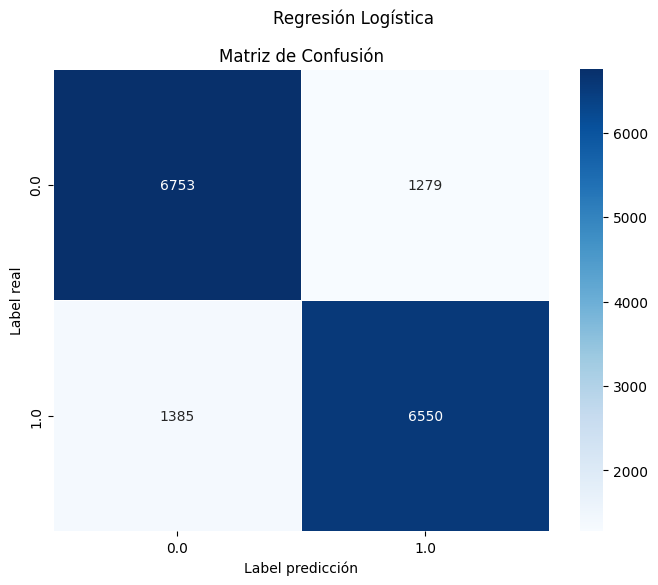

In [72]:
def plotMatConfusion(confMatrix, subtitulo):
    # confMatrix ya llega como DataFrame de Pandas, no necesita .toPandas()
    confMatrixPivote = confMatrix.pivot(
        index='label',
        columns='prediction',
        values='count'
    ).fillna(0)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(confMatrixPivote, annot=True, fmt='g',
                cmap='Blues',           # Paleta de color
                linewidths=0.5)         # Líneas entre celdas
    plt.suptitle(subtitulo)
    plt.title('Matriz de Confusión')
    plt.xlabel('Label predicción')
    plt.ylabel('Label real')
    plt.show()

# Y la llamada se mantiene igual:
confMatrixPandas = predLR.groupBy("label", "prediction") \
                         .count() \
                         .toPandas()    # ← aquí se convierte a Pandas
plotMatConfusion(confMatrixPandas, "Regresión Logística")

### Matriz de Confusión
- La matriz de confusión presenta con precisión dónde acierta y dónde falla el modelo. De los 8,032 clientes que realmente no suscribieron (label 0.0), el modelo clasificó correctamente a 6,753 como Verdaderos Negativos (TN) y tuvo 1,279 errores clasificándolos como Falsos Positivos (FP), es decir, predijo que suscribirían cuando en realidad no lo hicieron. De los 7,935 clientes que suscribieron (label 1.0), el modelo acertó en 6,550 casos identificándolos como Verdaderos Positivos (TP), pero falló en 1,385 casos etiquetándolos como Falsos Negativos (FN), es decir, predijo que no suscribirían cuando en realidad sí lo hicieron. En el contexto bancario, los Falsos Negativos (1,385 clientes) representan oportunidades de negocio perdidas, ya que son clientes con intención real de suscribir que el modelo no detectó, lo cual tiene un costo comercial mayor que los Falsos Positivos.

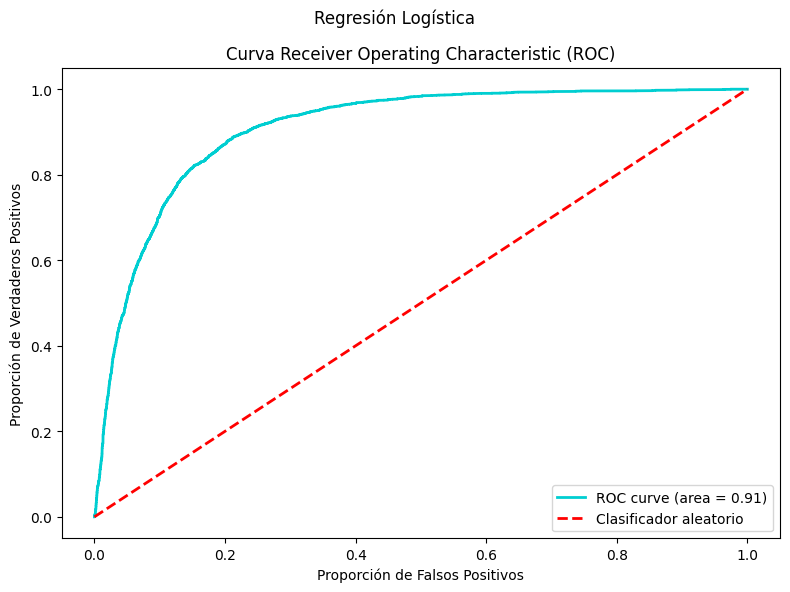

In [76]:
def plotROC(predictions, rocMetric, subtitulo):
    # Recolectar probabilidades y etiquetas desde Spark a memoria local
    # .collect() trae todos los datos del clúster → puede ser lento en datasets grandes
    probs  = predictions.select('probability').rdd.map(lambda row: float(row['probability'][1])).collect()
    labels = predictions.select('label').rdd.map(lambda row: float(row['label'])).collect()
    
    # Calcular curva ROC con sklearn
    fpr, tpr, thresholds = roc_curve(labels, probs)
    
    # Graficar
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr, tpr, color='darkturquoise', lw=2,
            label='ROC curve (area = %0.2f)' % rocMetric)
    ax.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--',
            label='Clasificador aleatorio')
    ax.set_xlabel('Proporción de Falsos Positivos')
    ax.set_ylabel('Proporción de Verdaderos Positivos')
    ax.set_title('Curva Receiver Operating Characteristic (ROC)')
    fig.suptitle(subtitulo)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(f'ROC_{subtitulo}.png', dpi=150, bbox_inches='tight')  # Guardar como respaldo
    plt.show()
    plt.close()

# Llamada
plotROC(predLR, aucLR, "Regresión Logística")


### Curva ROC
- La curva ROC refuerza visualmente la solidez del modelo, con un AUC de 0.91. La curva en turquesa se aparta al inicio de la línea base roja punteada (clasificador aleatorio con AUC = 0.5) y logra una Tasa de Verdaderos Positivos cercana al 80% con tan sólo un 10-15% de Falsos Positivos, lo que indica una excelente capacidad discriminatoria en umbrales conservadores. La forma característica de la curva, con una subida inicial muy pronunciada que luego se aplana cerca del valor 1.0, indica que el modelo es efectivo cuando se requiere detectar la mayoría de los clientes que sí suscribirán, a costa de un incremento moderado en falsos positivos. 
- Esta característica resulta importante en el contexto de campañas de marketing bancario, donde generalmente se prefiere contactar a algunos clientes de más (FP) antes que perder clientes con genuina intención de suscribir (FN).

# **2. RANDOM FOREST**

El Random Forest es un método de agrupamiento paralelo que crea 
varios árboles de decisión de forma independiente, entrenando cada uno 
sobre un subconjunto aleatorio del conjunto de datos y con un subconjunto aleatorio de variables. La predicción final es por votación mayoritaria
entre todos los árboles. Este factor aleatorio evita el sobreajuste. 
que sufriría un árbol individual. En este proyecto se 
entrenaron 100 árboles en paralelo en el clúster de Spark

Se utiliza cuando hay relaciones no lineales entre variables, 
cuando se requiere robustez a los valores atípicos y cuando se necesita minimizar la disminucion de los Falsos Negativos

In [77]:
from pyspark.ml.classification import RandomForestClassifier

instanciaRF = RandomForestClassifier(
    featuresCol='features',
    labelCol='label',
    numTrees=100,
    seed=42
)
modeloRF = instanciaRF.fit(trainData)
predRF   = modeloRF.transform(testData)

In [78]:
#Métricas
accuracyRF  = evaluadorLR.evaluate(predRF, {evaluadorLR.metricName: "accuracy"})
precisionRF = evaluadorLR.evaluate(predRF, {evaluadorLR.metricName: "weightedPrecision"})
recallRF    = evaluadorLR.evaluate(predRF, {evaluadorLR.metricName: "weightedRecall"})
f1RF        = evaluadorLR.evaluate(predRF, {evaluadorLR.metricName: "f1"})

evaluadorBinRF = BinaryClassificationEvaluator(
    labelCol='label',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
)
aucRF = evaluadorBinRF.evaluate(predRF)

print(" Métricas Random Forest: ")
print(f"Accuracy  : {accuracyRF:.4f}")
print(f"Precision : {precisionRF:.4f}")
print(f"Recall    : {recallRF:.4f}")
print(f"F1-Score  : {f1RF:.4f}")
print(f"AUC-ROC   : {aucRF:.4f}")

 Métricas Random Forest: 
Accuracy  : 0.8225
Precision : 0.8254
Recall    : 0.8225
F1-Score  : 0.8222
AUC-ROC   : 0.9000


# Comentarios Generales
- El modelo Random Forest con 100 árboles obtuvo un Accuracy de un 82,25%, una Precision de un 82,54%, un Recall de un 82,25% y un F1-Score de un 82,22%, resultados que son un poco inferiores a los de la Regresión Logística en todas las métricas de clasificación directa. El AUC-ROC de 0.90 queda también un punto porcentual por debajo del 0.91 que obtuvo el modelo baseline. Normalmente debería ser mas eficiente, ya que Random Forest es un modelo no lineal con mayor capacidad expresiva. Esto puede deberse a que los hiperparámetros no fueron optimizados (se usaron valores por defecto salvo numTrees=100) o que la variable Duracion, que es la más predictiva del dataset, favorece modelos lineales bien calibrados en este contexto particular.

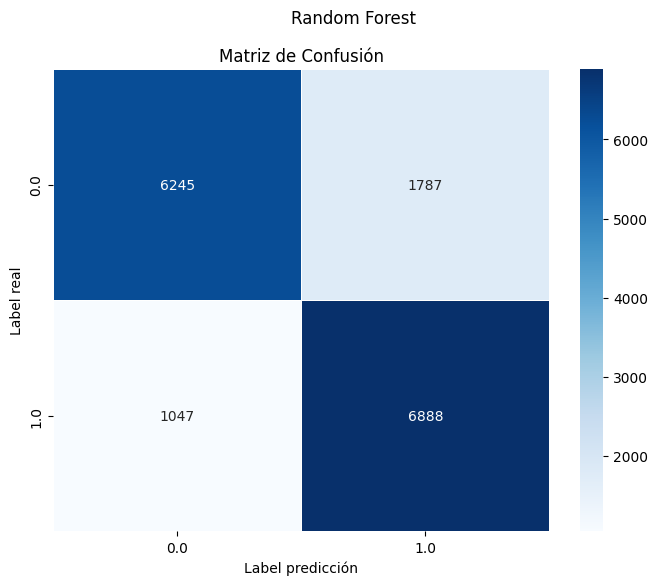

In [79]:
# --- Matriz de Confusión Random Forest ---
confMatrixRF = predRF.groupBy("label", "prediction").count().toPandas()
plotMatConfusion(confMatrixRF, "Random Forest")

# Matriz de confusión
- De los 8,032 clientes que en realidad no suscribieron (label 0.0), el modelo clasificó correctamente 6,245 como Verdaderos Negativos pero cometió 1,787 Falsos Positivos, un error mayor que el de la Regresión Logística (1,279 FP). 
- Por otro lado, para los 7,935 clientes que suscribieron (label 1.0), el Random Forest mejoró significativamente encontrando 6,888 Verdaderos Positivos en comparación con los 6,550 de la Regresión Logística, disminuyendo los Falsos Negativos de 1,385 a solo 1,047. 
- Random Forest es mejor para identificar a los clientes que sí se van a suscribir, aunque eso se traduce en más alertas falsas de clientes que no se van a suscribir. Esta característica puede ser preferible comercialmente, ya que al reducir los Falsos Negativos se pierden menos oportunidades de negocio reales.

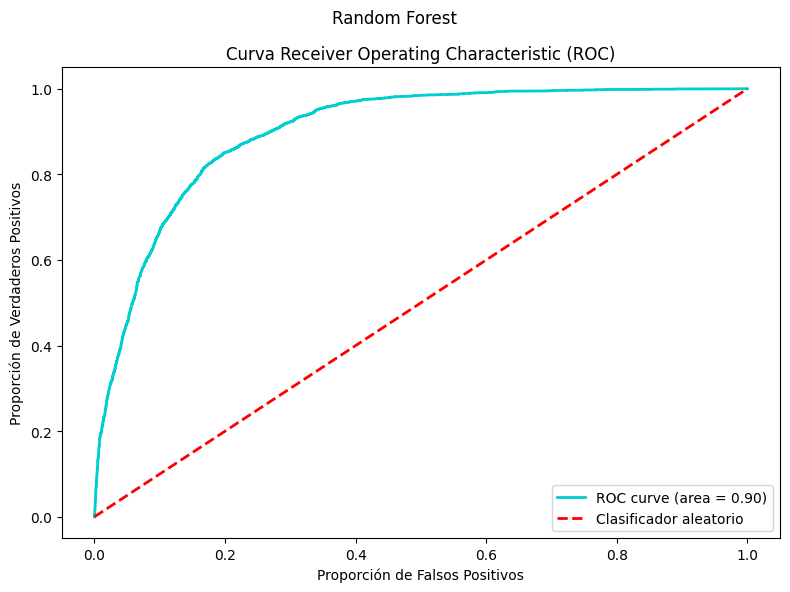

In [80]:
# --- Curva ROC Random Forest ---
plotROC(predRF, aucRF, "Random Forest")

# Curva de ROC
- La curva ROC del Random Forest con AUC de 0.90 muestra una forma similar a la de la Regresión Logística, con una subida inicial pronunciada que alcanza cerca del 80% de Verdaderos Positivos con un 15-20% de Falsos Positivos. 
- Si se comparan visualmente ambas curvas, la de Regresión Logística se aleja de la diagonal más temprano y de forma más pronunciada, lo que explica la diferencia de un punto en el AUC. 
- El Random Forest conserva una excelente capacidad discriminatoria, muy superior a la del clasificador aleatorio, pero no supera al modelo lineal en términos de ranking de probabilidades en este caso particular.

# **3. GRADIENT BOOSTED TREES**

El GBT es un método de agrupamiento secuencial, en el cual cada nuevo árbol se  entrena para corregir los errores del árbol anterior, minimizando una 
función de pérdida usando el descenso del gradiente. Al contrario que el 
Random Forest, los árboles no son independientes sino que se construyen 
uno encima del otro, lo que lo hace más exacto pero también más sensible a 
los hiperparámetros. Es considerado uno de los algoritmos más poderosos 
para datos estructurados en forma de tabla

Se emplea cuando se quiere el mejor rendimiento predictivo en datos tabulares y se dispone de suficiente capacidad computacional para realizar un entrenamiento secuencial

In [81]:
from pyspark.ml.classification import GBTClassifier

instanciaGBT = GBTClassifier(
    featuresCol='features',
    labelCol='label',
    maxIter=10,
    seed=42
)
modeloGBT = instanciaGBT.fit(trainData)
predGBT   = modeloGBT.transform(testData)

In [82]:
# Métricas
accuracyGBT  = evaluadorLR.evaluate(predGBT, {evaluadorLR.metricName: "accuracy"})
precisionGBT = evaluadorLR.evaluate(predGBT, {evaluadorLR.metricName: "weightedPrecision"})
recallGBT    = evaluadorLR.evaluate(predGBT, {evaluadorLR.metricName: "weightedRecall"})
f1GBT        = evaluadorLR.evaluate(predGBT, {evaluadorLR.metricName: "f1"})

evaluadorBinGBT = BinaryClassificationEvaluator(
    labelCol='label',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
)
aucGBT = evaluadorBinGBT.evaluate(predGBT)

print(" Métricas Gradient Boosted Trees: ")
print(f"Accuracy  : {accuracyGBT:.4f}")
print(f"Precision : {precisionGBT:.4f}")
print(f"Recall    : {recallGBT:.4f}")
print(f"F1-Score  : {f1GBT:.4f}")
print(f"AUC-ROC   : {aucGBT:.4f}")

 Métricas Gradient Boosted Trees: 
Accuracy  : 0.8351
Precision : 0.8359
Recall    : 0.8351
F1-Score  : 0.8350
AUC-ROC   : 0.9122


# Comentarios Generales
- El modelo de Gradient Boosted Trees fue el que obtuvo mejor desempeño global de los tres modelos evaluados, con un Accuracy de 83.51%, Precision de 83.59%, Recall de 83.51%, F1-Score de 83.50% y un AUC-ROC de 0.9122. 
- En todas las métricas supera a la Regresión Logística y con mayor margen al Random Forest, confirmando así que un modelo basado en ensamble secuencial de árboles sería el que mejor capturaría las relaciones no lineales entre variables como Duracion, Campaña_Marketing o Numero_dias. 
- El AUC-ROC más alto es de 0.9122, esto significa que GBT tiene la mejor capacidad de ordenar y discriminar entre clientes propensos y no propensos a suscribir.

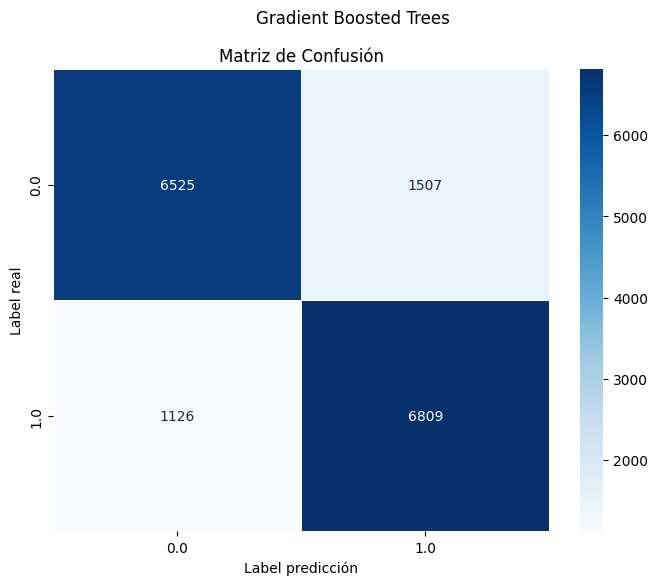

In [83]:
# Matriz de Confusión 
confMatrixGBT = predGBT.groupBy("label", "prediction").count().toPandas()
plotMatConfusion(confMatrixGBT, "Gradient Boosted Trees")

# Matriz de Confusión
- De los 8,032 clientes que en realidad no se suscribieron (label 0.0), GBT correctamente clasificó 6,525 como Verdaderos Negativos con 1,507 Falsos Positivos, un resultado intermedio entre la Regresión Logística (1,279 FP) y el Random Forest (1,787 FP). 
- Para los 7,935 clientes que sí suscribieron (label 1.0), detectó correctamente 6,809 Verdaderos Positivos con tan solo 1,126 Falsos Negativos, superando a la Regresión Logística (1,385 FN) aunque ligeramente por encima del Random Forest (1,047 FN). De esta manera, el GBT logra el mejor equilibrio entre ambos tipos de error: reduce considerablemente los Falsos Negativos respecto al baseline, sin disparar los Falsos Positivos como lo hace el Random Forest, convirtiéndose así en el modelo más balanceado y robusto de los tres.

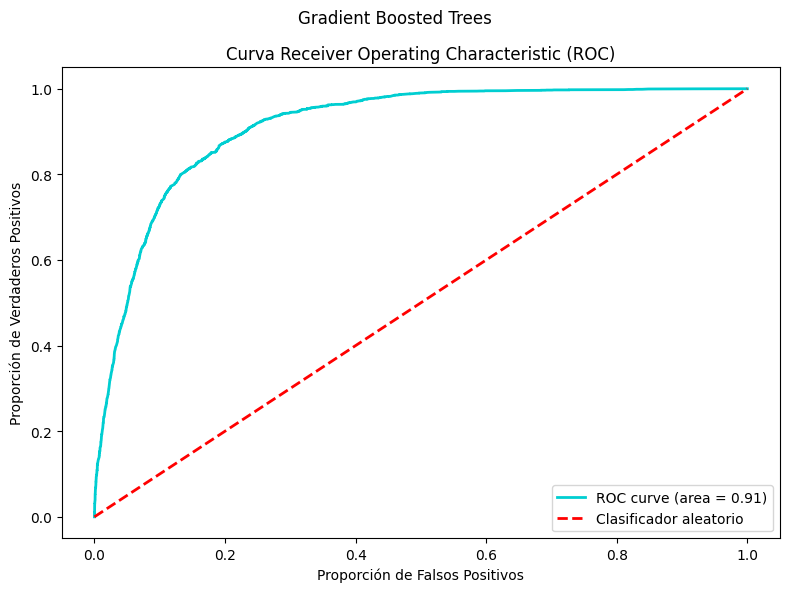

In [84]:
# Curva ROC 
plotROC(predGBT, aucGBT, "Gradient Boosted Trees")

# Curva ROC
- De los tres modelos, la curva ROC del GBT es la más pronunciada visualmente. Con un AUC de 0.91, la curva turquesa se aleja de la diagonal roja, alcanzando aproximadamente un 80% de Verdaderos Positivos con apenas un 8-10% de Falsos Positivos, un desempeño superior al observado en Regresión Logística y Random Forest en esa zona crítica de bajo FPR. Esta característica es útil si se intenta localizar clientes potenciales realizando el menor número posible de llamadas innecesarias.

# **4. Decision Tree**

El árbol de decisión clasifica haciendo sucesivas preguntas binarias 
sobre las variables del dataset hasta llegar a una hoja con la etiqueta 
predicción. Es el modelo más intuitivo y de más fácil visualización de todos los evaluados. Su mayor complicación es que tiende a sobreajustarse cuando 
el árbol crece demasiado, por lo que se controló su profundidad máxima 
con el parámetro `maxDepth = 10`.

Se usa cuando se necesita un modelo que interprete y explique muy rápido, o cuando el objetivo principal es maximizar el Accuracy con el umbral por defecto de 0.5

In [85]:
from pyspark.ml.classification import DecisionTreeClassifier

# Se instancia el modelo de Árbol de Decisión
instanciaDT = DecisionTreeClassifier(
    featuresCol='features',
    labelCol='label',
    maxDepth=10, # profundidad máxima del árbol, controla la complejidad
    minInstancesPerNode=5, # mínimo de registros por nodo hoja, evita sobreajuste
    seed=42 #semilla para reproducibilidad
)

modeloDT = instanciaDT.fit(trainData)   # Entrenamiento sobre conjunto de entrenamiento
predDT   = modeloDT.transform(testData) # Predicciones sobre conjunto de prueba

In [86]:
accuracyDT  = evaluadorLR.evaluate(predDT, {evaluadorLR.metricName: "accuracy"})
precisionDT = evaluadorLR.evaluate(predDT, {evaluadorLR.metricName: "weightedPrecision"})
recallDT    = evaluadorLR.evaluate(predDT, {evaluadorLR.metricName: "weightedRecall"})
f1DT        = evaluadorLR.evaluate(predDT, {evaluadorLR.metricName: "f1"})

evaluadorBinDT = BinaryClassificationEvaluator(
    labelCol='label',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
)
aucDT = evaluadorBinDT.evaluate(predDT)

print("Métricas Decision Tree: ")
print(f"Accuracy  : {accuracyDT:.4f}")
print(f"Precision : {precisionDT:.4f}")
print(f"Recall    : {recallDT:.4f}")
print(f"F1-Score  : {f1DT:.4f}")
print(f"AUC-ROC   : {aucDT:.4f}")

=== Métricas Decision Tree ===
Accuracy  : 0.8657
Precision : 0.8662
Recall    : 0.8657
F1-Score  : 0.8657
AUC-ROC   : 0.7401


# Comentarios Generales
- Con un 86.57% de Accuracy, es el modelo con el mejor resultado de todos los cuatro, por delante del GBT (83.51%), la Regresión Logística (83.32%) y el Random Forest (82.25%), pero su AUC-ROC es el más bajo de todos los cuatro modelos, con apenas un 0.7401, muy por debajo del umbral de 0.90 que sí superan los otros tres
- Este contraste nos dice algo importante sobre el funcionamiento del árbol de decisión: es muy bueno tomando decisiones binarias concretas con el umbral por defecto de 0.5, pero sus probabilidades internas no están bien calibradas, y esto se refleja en una curva ROC que no captura bien el espectro completo de umbrales posibles

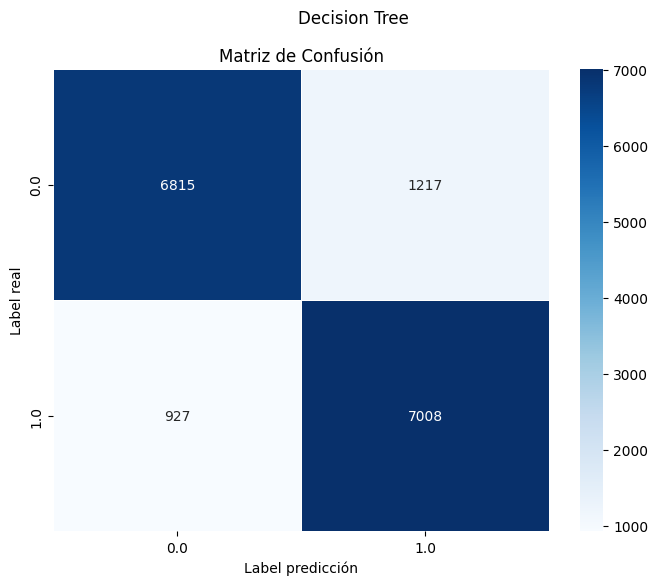

In [87]:
confMatrixPandas = predDT.groupBy("label", "prediction") \
                         .count() \
                         .toPandas()
plotMatConfusion(confMatrixPandas, "Decision Tree")

# Matriz de Confusión
- La matriz muestra el mejor desempeño en detección de la clase positiva de todos los modelos analizados, de los 7,935 clientes que sí suscribieron (label 1.0), el Decision Tree detectó correctamente 7,008 como Verdaderos Positivos, cometiendo solo 927 Falsos Negativos, la cifra más baja de todos los modelos
- En cuanto a la clase negativa, obtuvo una tasa intermedia entre los otros modelos clasificando correctamente 6.815 de los 8.032 no suscriptores con 1.217 Falsos Positivos
- En la práctica, el Decision Tree es el mejor modelo para minimizar clientes interesados no detectados, lo que, en un contexto de campaña bancaria donde cada cliente perdido tiene un costo comercial directo

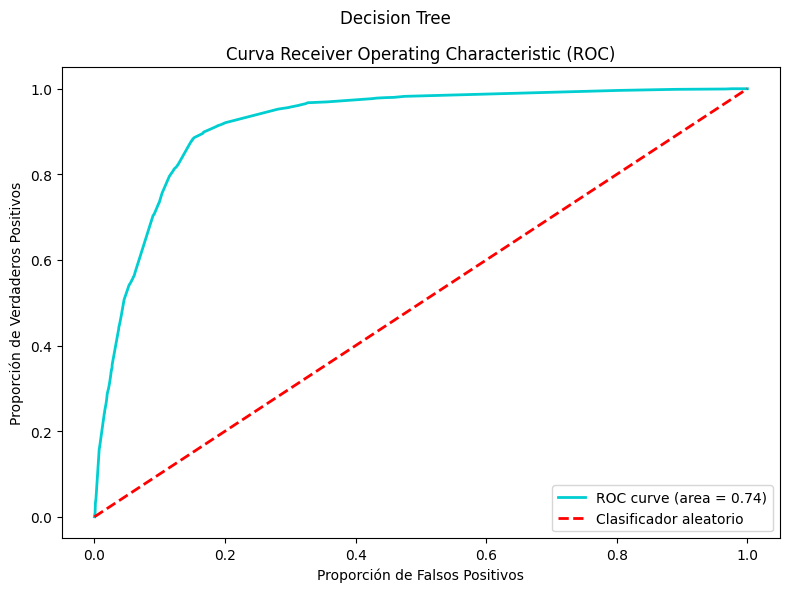

In [88]:
plotROC(predDT, aucDT, "Decision Tree")

# Curva ROC
- La curva ROC con AUC de 0.74 está por debajo de las otras curvas de los distintos modelos. Si bien se aleja de la diagonal roja y muestra un salto pronunciado en los primeros valores de FPR, la curva se aplana rápidamente y no mantiene la ventaja sostenida que sí muestran GBT y Regresión Logística a lo largo de todo el espectro
- El árbol toma decisiones correctas en los casos más claros pero pierde discriminación en los casos ambiguos, donde las probabilidades intermedias son poco confiables
- La diferencia entre un Accuracy de 86.57% y un AUC de 0.74 representa la distinción de un modelo que memoriza patrones claros del conjunto de entrenamiento pero no generaliza correctamente la incertidumbre probabilística

# **5. Linear SVC**

El Linear SVC busca el hiperplano óptimo que permite separar las dos clases y maximizar el margen entre ellas. Al contrario de los anteriores modelos, 
no produce directamente probabilidades, sino una puntuación de confianza
(`rawPrediction`) que indica en qué lado del hiperplano cae cada registro. 
Es eficiente desde el punto de vista computacional y efectivo cuando las las clases son linealmente separables. El parámetro `regParam` permite regular el compromiso entre el máximo margen y los errores de clasificación.

Se usa cuando las clases están separadas linealmente en su mayor parte y requiere un modelo rápido y robusto con buen AUC-ROC.

In [89]:
from pyspark.ml.classification import LinearSVC

# Linear SVC busca el hiperplano óptimo que separa las dos clases maximizando el margen entre ellas

instanciaSVC = LinearSVC(
    featuresCol='features',
    labelCol='label',
    maxIter=100, #número máximo de iteraciones del optimizador
    regParam=0.01, #parámetro de regularización L2 para evitar sobreajuste
    standardization=True #estandariza las features internamente
)

modeloSVC = instanciaSVC.fit(trainData)
predSVC   = modeloSVC.transform(testData)

In [90]:
accuracySVC  = evaluadorLR.evaluate(predSVC, {evaluadorLR.metricName: "accuracy"})
precisionSVC = evaluadorLR.evaluate(predSVC, {evaluadorLR.metricName: "weightedPrecision"})
recallSVC    = evaluadorLR.evaluate(predSVC, {evaluadorLR.metricName: "weightedRecall"})
f1SVC        = evaluadorLR.evaluate(predSVC, {evaluadorLR.metricName: "f1"})

evaluadorBinSVC = BinaryClassificationEvaluator(
    labelCol='label',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
)
aucSVC = evaluadorBinSVC.evaluate(predSVC)

print("Métricas Linear SVC: ")
print(f"Accuracy  : {accuracySVC:.4f}")
print(f"Precision : {precisionSVC:.4f}")
print(f"Recall    : {recallSVC:.4f}")
print(f"F1-Score  : {f1SVC:.4f}")
print(f"AUC-ROC   : {aucSVC:.4f}")

=== Métricas Linear SVC ===
Accuracy  : 0.8345
Precision : 0.8345
Recall    : 0.8345
F1-Score  : 0.8345
AUC-ROC   : 0.9081


# Comentarios Generales
- El Linear SVC alcanza un Accuracy, Precision, Recall y F1-Score del 83.45%, resultados notablemente simétricos entre todas las métricas que reflejan un comportamiento perfectamente equilibrado entre clases
- Con un AUC-ROC de 0,9081 se ubica en el tercer lugar en capacidad discriminatoria, muy cerca de la Regresión Logística (0,9076) y apenas detrás del GBT (0,9122)
- El SVC lineal busca el hiperplano óptimo que maximiza el margen entre clases, lo que genera clasificaciones bien calibradas en problemas donde existe una componente lineal significativa en la separación de clases, en este caso, la Duracion tiene una relación casi lineal con la suscripción

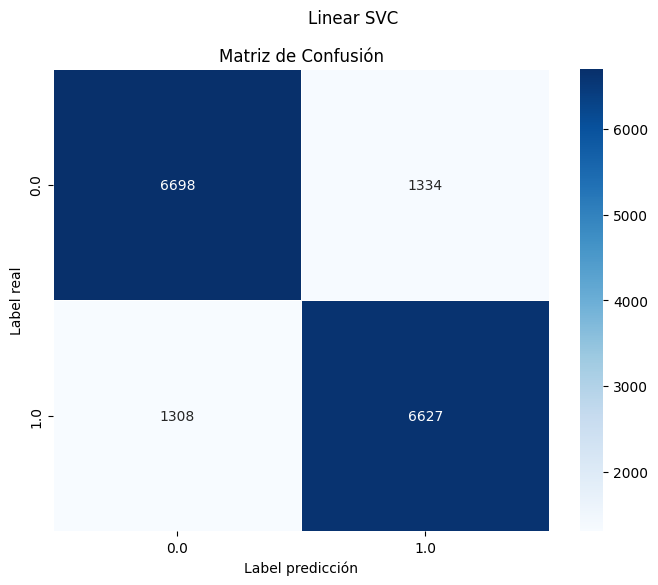

In [91]:
confMatrixPandas = predSVC.groupBy("label", "prediction") \
                          .count() \
                          .toPandas()
plotMatConfusion(confMatrixPandas, "Linear SVC")

# Matriz de Confusión
- De los 8,032 clientes que no suscribieron, el modelo clasificó correctamente 6,698 como Verdaderos Negativos con 1,334 Falsos Positivos, un nivel similar a GBT y la Regresión Logística
- De los 7,935 clientes que sí se suscribieron, detectó 6,627 Verdaderos Positivos con 1,308 Falsos Negativos. El SVC presenta un número muy similar de errores en ambas clases (1.334 FP vs 1.308 FN): al optimizar el margen de separación de forma simétrica entre clases tiende a distribuir los errores de manera más equilibrada que otros algoritmos, lo que explica la perfecta igualdad entre todas sus métricas.

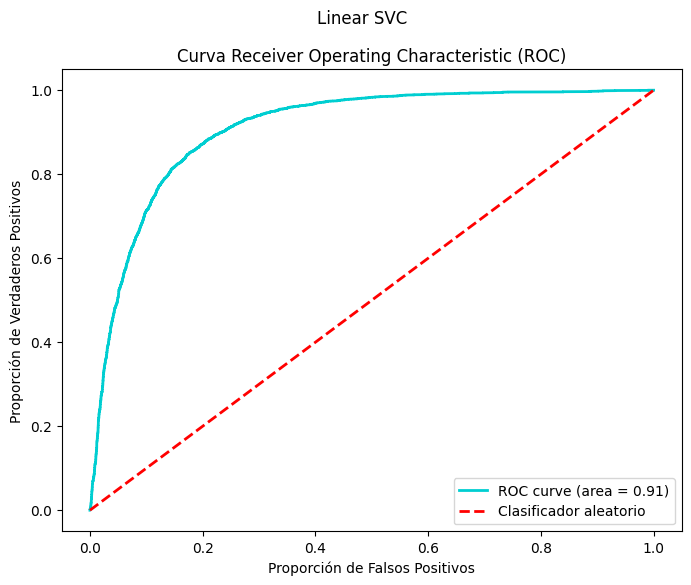

In [92]:
rawPreds = predSVC.select('rawPrediction').rdd.map(
    lambda row: float(row['rawPrediction'][1])
)
labels   = predSVC.select('label').rdd.map(lambda row: row['label'])

fpr, tpr, _ = roc_curve(labels.collect(), rawPreds.collect())

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkturquoise', lw=2,
         label='ROC curve (area = %0.2f)' % aucSVC)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--',
         label='Clasificador aleatorio')
plt.xlabel('Proporción de Falsos Positivos')
plt.ylabel('Proporción de Verdaderos Positivos')
plt.title('Curva Receiver Operating Characteristic (ROC)')
plt.suptitle('Linear SVC')
plt.legend(loc='lower right')
plt.show()

# Curva ROC
- La curva ROC con AUC de 0.91 es visualmente muy similar a la de Regresión Logística y el GBT, con una subida inicial pronunciada que llega aproximadamente al 80% de Verdaderos Positivos con solo el 10-15% de Falsos Positivos
- A lo largo de todos los umbrales, la curva conserva una ventaja continua respecto a la diagonal roja, lo que corrobora que el modelo posee una capacidad discriminatoria bien distribuida
- El Linear SVC calculo curva ROC utilizando rawPrediction en lugar de probabilidades directas, ya que este algoritmo no produce probabilidades calibradas nativamente, lo que puede introducir una ligera imprecisión en la curva respecto a modelos probabilísticos como la Regresión Logística o el GBT

# **6. Multilayer Perceptron**

In [106]:
from pyspark.ml.classification import MultilayerPerceptronClassifier

# Red neuronal con arquitectura:
# Capa de entrada: número de features del vector ensamblado
# Capa oculta 1: 64 neuronas
# Capa oculta 2: 32 neuronas
# Capa de salida: 2 neuronas (clases: 0 y 1)

# Primero se obtiene el número de features del vector
num_features = len(trainData.select('features').first()[0])

layers = [num_features, 64, 32, 2]   # Arquitectura de la red

instanciaMLP = MultilayerPerceptronClassifier(
    featuresCol='features',
    labelCol='label',
    layers=layers,
    maxIter=100, # épocas de entrenamiento
    seed=42, #reproducibilidad
    blockSize=128,      # Tamaño del bloque para el optimizador
    stepSize=0.03       # Tasa de aprendizaje
)

modeloMLP = instanciaMLP.fit(trainData)
predMLP   = modeloMLP.transform(testData)

In [107]:
accuracyMLP  = evaluadorLR.evaluate(predMLP, {evaluadorLR.metricName: "accuracy"})
precisionMLP = evaluadorLR.evaluate(predMLP, {evaluadorLR.metricName: "weightedPrecision"})
recallMLP    = evaluadorLR.evaluate(predMLP, {evaluadorLR.metricName: "weightedRecall"})
f1MLP        = evaluadorLR.evaluate(predMLP, {evaluadorLR.metricName: "f1"})

evaluadorBinMLP = BinaryClassificationEvaluator(
    labelCol='label',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
)
aucMLP = evaluadorBinMLP.evaluate(predMLP)

print("Métricas Multilayer Perceptron: ")
print(f"Accuracy  : {accuracyMLP:.4f}")
print(f"Precision : {precisionMLP:.4f}")
print(f"Recall    : {recallMLP:.4f}")
print(f"F1-Score  : {f1MLP:.4f}")
print(f"AUC-ROC   : {aucMLP:.4f}")

Métricas Multilayer Perceptron: 
Accuracy  : 0.7193
Precision : 0.7251
Recall    : 0.7193
F1-Score  : 0.7177
AUC-ROC   : 0.7973


# Comentarios Generales
- El Multilayer Perceptron es el modelo con peor desempeño global de los seis analizados, logrando un Accuracy de 71,93%, una Precision de 72,51%, un Recall de 72,93%, un F1-Score de 71,77% y un AUC-ROC de 0,7973
- La red neuronal implementada se entrenó con tan sólo 100 iteraciones (maxIter=100) con una arquitectura de dos capas ocultas (64 y 32 neuronas), lo cual en el contexto de un clúster Spark con recursos limitados resulta insuficiente para que la red converja a una solución óptima

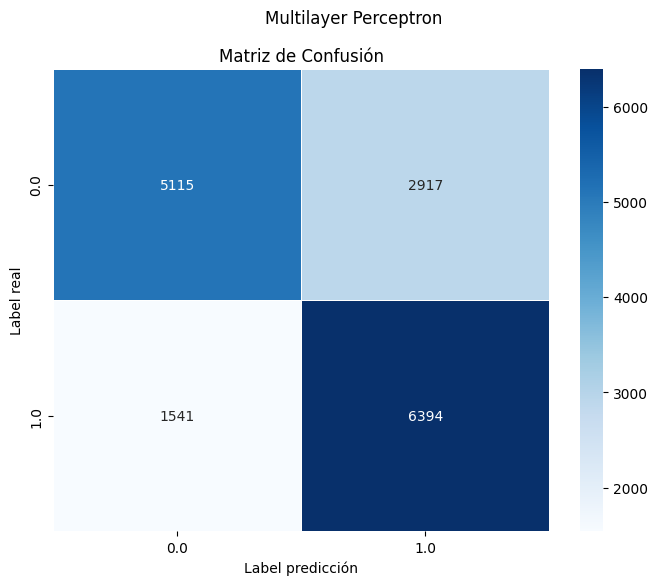

In [95]:
confMatrixPandas = predMLP.groupBy("label", "prediction") \
                          .count() \
                          .toPandas()
plotMatConfusion(confMatrixPandas, "Multilayer Perceptron")

# Matriz de Confusión
- La matriz muestra el problema con más claridad: del total de clientes que no suscribieron, el modelo clasificó erróneamente a 2.917 como Falsos Positivos, la cifra más alta de todos los modelos, más del doble que el GBT (1.507) o la Regresión Logística (1.279)
- De los 7,935 clientes que sí se suscribieron , detectó 6,394 Verdaderos Positivos con 1,541 Falsos Negativos, un desempeño peor al Decision Tree (927 FN) y al Random Forest (1,047 FN)
- El patrón general indica que la red tiende a sesgarse hacia la predicción de la clase positiva (1.0), tal vez porque el oversampling utilizado en el preprocesamiento creó patrones repetitivos que la red memorizó parcialmente sin lograr una buena generalización hacia la clase negativa

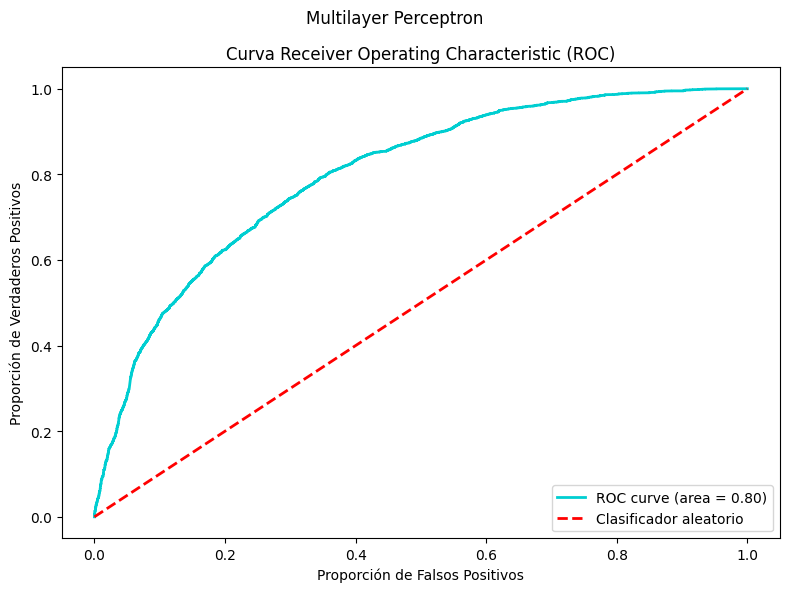

In [96]:
plotROC(predMLP, aucMLP, "Multilayer Perceptron")

# Curva ROC
- La curva ROC con AUC de 0.80 tiene una forma más gradual y menos abrupta que la de los otros modelos, careciendo del salto inicial agresivo que presentan GBT, Regresión Logística y Linear SVC. La curva se eleva de forma más lineal, alcanzando el 60% de TPR con un 20% de FPR, un rendimiento claramente inferior al de los modelos anteriores en esa zona crítica
- Sin embargo, el AUC de 0.80 sigue siendo superior al clasificador aleatorio (0.50) y al Decision Tree (0.74) en términos de discriminación probabilística, lo que indica que la red aprendió patrones relevantes aunque de forma incompleta

# **COMPARATIVA DE MODELOS**

In [97]:
comparacion = pd.DataFrame({
    'Modelo': [
        'Regresión Logística',
        'Random Forest',
        'GBT',
        'Decision Tree',
        'Linear SVC',
        'Multilayer Perceptron'
    ],
    'Accuracy':  [accuracyLR,  accuracyRF,  accuracyGBT,  accuracyDT,  accuracySVC,  accuracyMLP],
    'Precision': [precisionLR, precisionRF, precisionGBT, precisionDT, precisionSVC, precisionMLP],
    'Recall':    [recallLR,    recallRF,    recallGBT,    recallDT,    recallSVC,    recallMLP],
    'F1-Score':  [f1LR,        f1RF,        f1GBT,        f1DT,        f1SVC,        f1MLP],
    'AUC-ROC':   [aucLR,       aucRF,       aucGBT,       aucDT,       aucSVC,       aucMLP]
})

print("Comparación final de modelos")
print(comparacion.to_string(index=False))

Comparación final de modelos
               Modelo  Accuracy  Precision   Recall  F1-Score  AUC-ROC
  Regresión Logística  0.833156   0.833201 0.833156  0.833142 0.907603
        Random Forest  0.822509   0.825401 0.822509  0.822177 0.899956
                  GBT  0.835097   0.835910 0.835097  0.835027 0.912209
        Decision Tree  0.865723   0.866236 0.865723  0.865694 0.740065
           Linear SVC  0.834534   0.834541 0.834534  0.834535 0.908116
Multilayer Perceptron  0.720799   0.727845 0.720799  0.718859 0.796551


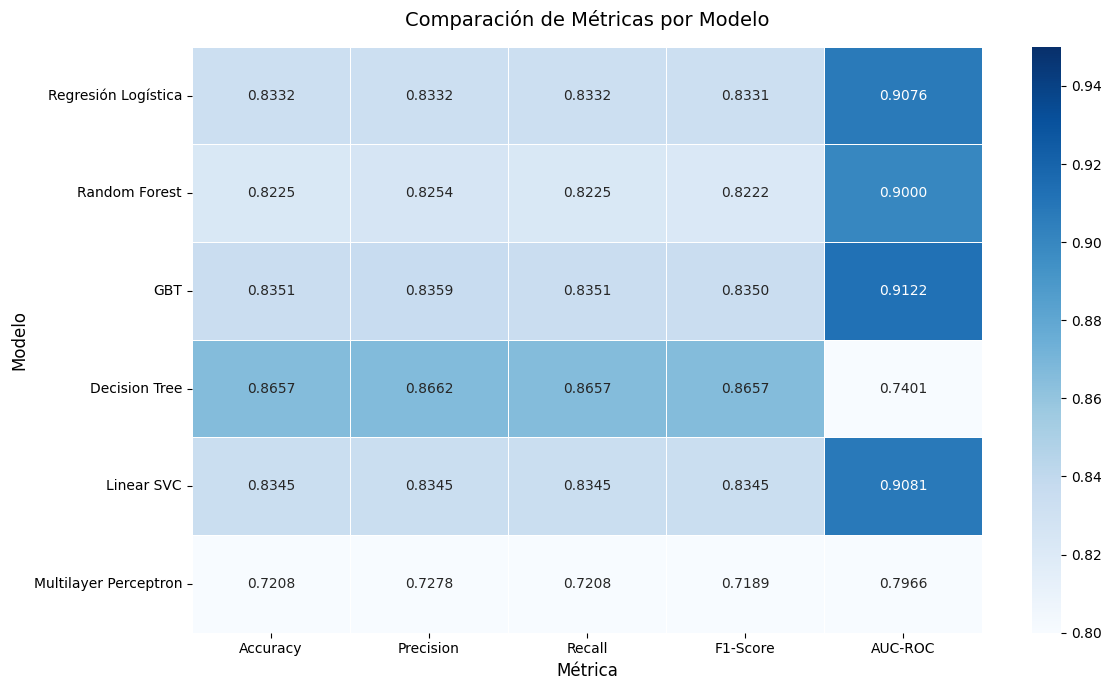

In [98]:
plt.figure(figsize=(12, 7))
sns.heatmap(
    comparacion.set_index('Modelo'),
    annot=True,
    fmt='.4f',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    vmin=0.80,          # Límite inferior de la escala de color
    vmax=0.95           # Límite superior de la escala de color
)
plt.title('Comparación de Métricas por Modelo', fontsize=14, pad=15)
plt.xlabel('Métrica', fontsize=12)
plt.ylabel('Modelo', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Conclusiones Finales
- El heatmap de comparación resume los resultados de los seis modelos evaluados, donde el azul más oscuro representa un mayor valor de cada métrica. Los colores más oscuros se ven en la columna AUC-ROC para los modelos probabilísticos, y en las columnas de clasificación directa para el Decision Tree, lo que ya visualmente anticipa la paradoja central de este comparativo
  
- Cuatro de los seis modelos (GBT, Regresión Logística, Linear SVC y Random Forest) presentan un rendimiento muy similar entre sí en las métricas de clasificación directa, todas situadas en el rango del 0.82 al 0.84, mientras que el Decision Tree y el Multilayer Perceptron se separan del grupo por razones opuestas
- El Gradient Boosted Trees se posiciona como el mejor modelo a nivel global, obteniendo un Accuracy de 0.8351, una Precision de 0.8359, un Recall de 0.8351, un F1-Score de 0.8350 y el AUC-ROC más alto de todos los modelos. Su ventaja sobre la Regresión Logística es pequeña en las métricas de clasificación directa, pero el AUC-ROC superior confirma que GBT genera probabilidades mejor calibradas y más discriminativas, lo que lo hace más confiable para segmentar clientes por nivel de riesgo o propensión, como quedó demostrado en el análisis de segmentación por score donde el segmento de alta prioridad tuvo una tasa de conversión real del 93.46%
  
- La Regresión Logística se acerca mucho al GBT, con un AUC-ROC de 0,9076 que la convierte en el segundo modelo más discriminatorio del comparativo. Esto refuerza la idea de que cuando las relaciones entre variables tienen una componente lineal importante, como es el caso de Duracion en este dataset, los modelos lineales bien entrenados pueden rivalizar con modelos mucho más complejos. Su ganancia adicional es la interpretabilidad: los coeficientes del modelo hacen posible explicar directamente qué variables impulsan la predicción, algo valioso en el contexto bancario donde la regulación puede requerir modelos explicables
  
- El Linear SVC sorprende con un AUC-ROC de 0.9081, su comportamiento perfectamente simétrico entre todas las métricas de clasificación directa. Su principal limitación es que no poseen probabilidades propias bien calibradas, lo que restringe su uso en escenarios de segmentación por score como el desarrollado con el GBT
  
- El único modelo del grupo de cuatro competitivos que queda por debajo de los demás en todas las métricas globales es el Random Forest. Sin embargo, tiene la ventaja de haber generado la menor cantidad de Falsos Negativos (1,047), por lo cual se constituye en la mejor opción cuando el objetivo de negocio prioriza absolutamente no perder clientes con intención real de suscribir
  
- El Decision Tree es el modelo con el Accuracy más alto de todos y el menor número de Falsos Negativos absolutos, pero al mismo tiempo tiene el AUC-ROC más bajo del grupo con buen rendimiento. Esta contradicción se explica porque el árbol toma decisiones muy certeras con el umbral por defecto de 0.5 memorizando patrones claros del conjunto de entrenamiento, pero sus probabilidades internas no están bien calibradas para discriminar en el espectro completo de umbrales posibles. Para campañas donde se requiere una lista ordenada de clientes por probabilidad de conversión, el Decision Tree no es adecuado, mientras que para campañas de contacto masivo donde solo se necesita una decisión binaria rápida, es la mejor herramienta


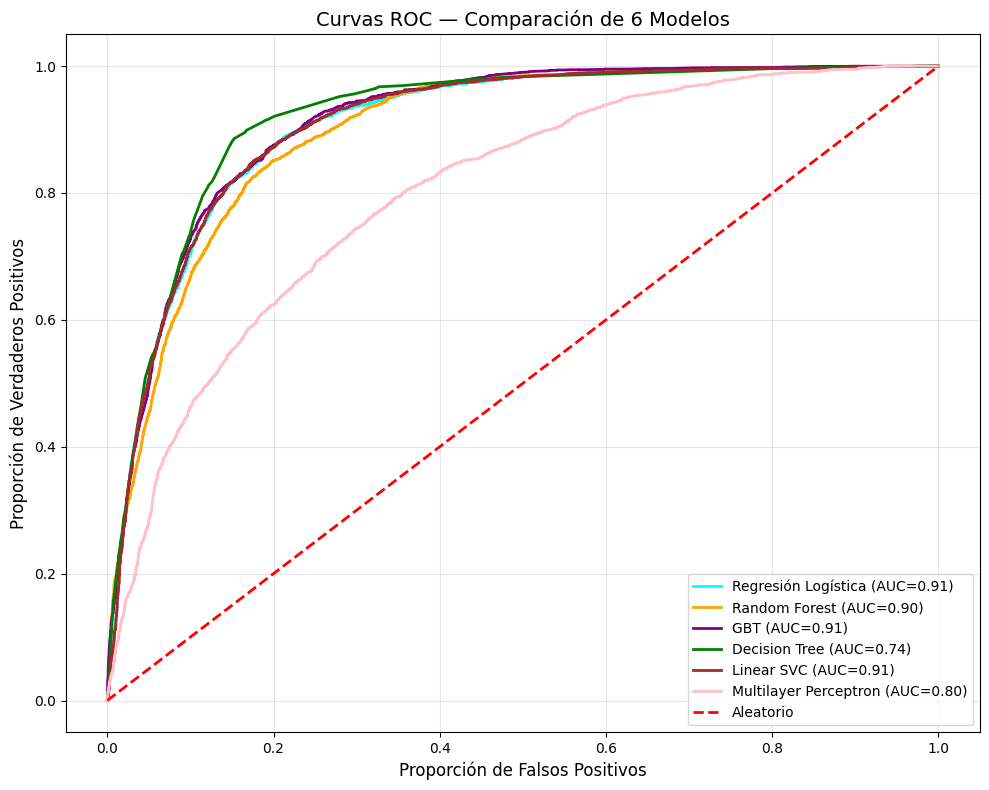

In [101]:
# Función auxiliar para extraer FPR y TPR de cada modelo
def getFPR_TPR(predictions, useRaw=False):
    if useRaw:
        probs = predictions.select('rawPrediction').rdd.map(
            lambda row: float(row['rawPrediction'][1])
        )
    else:
        probs = predictions.select('probability').rdd.map(
            lambda row: float(row['probability'][1])
        )
    labels = predictions.select('label').rdd.map(lambda row: row['label'])
    fpr, tpr, _ = roc_curve(labels.collect(), probs.collect())
    return fpr, tpr

# Configuración de colores y estilos por modelo
modelos_config = [
    (predLR,  aucLR,  'Regresión Logística',    'cyan',      False),
    (predRF,  aucRF,  'Random Forest',           'orange',    False),
    (predGBT, aucGBT, 'GBT',                    'purple',    False),
    (predDT,  aucDT,  'Decision Tree',           'green',     False),
    (predSVC, aucSVC, 'Linear SVC',              'brown',     True),
    (predMLP, aucMLP, 'Multilayer Perceptron',   'pink',      False),
]

plt.figure(figsize=(10, 8))

for pred, auc_val, nombre, color, useRaw in modelos_config:
    fpr, tpr = getFPR_TPR(pred, useRaw)
    plt.plot(fpr, tpr, lw=2, color=color,
             label=f'{nombre} (AUC={auc_val:.2f})')

# Línea base del clasificador aleatorio
plt.plot([0, 1], [0, 1], color='red', lw=2,
         linestyle='--', label='Aleatorio')

plt.xlabel('Proporción de Falsos Positivos', fontsize=12)
plt.ylabel('Proporción de Verdaderos Positivos', fontsize=12)
plt.title('Curvas ROC — Comparación de 6 Modelos', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Curva ROC
- Los tres con mejor rendimiento son GBT (morado), Regresión Logística (cian) y Linear SVC (cafe oscuro), que muestran un AUC de 0.91, y son prácticamente indistinguibles a lo largo de casi todo el espectro. Las tres se apartan de la diagonal roja muy pronto y de forma marcada, llegando a rondar entre el 75-80% de Verdaderos Positivos con apenas un 10% de Falsos Positivos, que es la zona más valiosa de la curva para una campaña bancaria donde se quiere contactar con pocos clientes pero con alta probabilidad de conversión. A partir del 25% de FPR, las tres curvas coinciden perfectamente

- El Random Forest (naranja, AUC=0.90) está ligeramente por debajo de este trío en la zona crítica de bajo FPR. Esta separación, pequeña en números, tiene implicaciones prácticas: en un escenario donde el banco contacta solo el 10% de la base más probable, el modelo Random Forest identificaría menos suscriptores reales que los tres modelos superiores

- El Decision Tree (verde, AUC=0.74) tiene un incremento inicial que lo coloca por encima de todos los demás modelos en los primeros valores de FPR (0% a 15%), llegando casi al 90% de TPR con solo el 15% de FPR. A partir de ahí, sin embargo, la curva se aplana rápidamente y cae por debajo de todos los modelos probabilísticos, lo que explica su bajo AUC global de 0,74

- El Multilayer Perceptron (rosa claro, AUC=0.80) es la más alejada del grupo, con una trayectoria más gradual y lineal que confirma su menor rendimiento. Este se mantiene por encima de la diagonal roja en todo momento, su separación es mucho menor que el resto, especialmente en la zona entre 10% y 50% de FPR donde los otros modelos ya han capturado prácticamente toda la clase positiva y el MLP apenas llega al 60-70% de TPR

- Juntos, los gráficos confirman que para este dataset y con las condiciones de entrenamiento utilizadas, GBT, Regresión Logística y Linear SVC son equivalentes en capacidad discriminatoria y representan el techo de rendimiento alcanzado, con el GBT conservando una ventaja marginal que solo se puede observar al comparar los valores numéricos de AUC con cuatro decimales. El Decision Tree, a pesar de su bajo AUC global, se reconoce por su rendimiento en la zona de muy bajo FPR, lo que lo hace una herramienta válida para estrategias de contacto ultra-selectivo donde solo se quiere llamar al 5-10% de clientes con mayor certeza de conversión

In [99]:
# Obtener los metadatos del vector de features desde el schema
atributos = (modelo.schema["features"]
             .metadata["ml_attr"]["attrs"])

# Combinar atributos numéricos y binarios en un solo diccionario
# {índice: nombre_del_feature}
todosAtributos = {}
if "numeric" in atributos:
    for a in atributos["numeric"]:
        todosAtributos[a["idx"]] = a["name"]
if "binary" in atributos:
    for a in atributos["binary"]:
        todosAtributos[a["idx"]] = a["name"]

# Construir lista ordenada por índice
nombresFeatures = [todosAtributos[i] for i in sorted(todosAtributos.keys())]
print(f"Total features expandidos: {len(nombresFeatures)}")
print(nombresFeatures)  # Verifica que los nombres se ven bien

Total features expandidos: 41
['trabajo_oneHot_management', 'trabajo_oneHot_blue-collar', 'trabajo_oneHot_technician', 'trabajo_oneHot_admin.', 'trabajo_oneHot_services', 'trabajo_oneHot_retired', 'trabajo_oneHot_self-employed', 'trabajo_oneHot_student', 'trabajo_oneHot_unemployed', 'trabajo_oneHot_entrepreneur', 'trabajo_oneHot_housemaid', 'Estado_Civil_oneHot_married', 'Estado_Civil_oneHot_single', 'Educacion_oneHot_secondary', 'Educacion_oneHot_tertiary', 'Educacion_oneHot_primary', 'Credito_Incumplimiento_oneHot_no', 'Prestamo_Hipotecario_oneHot_no', 'Prestamo_Personal_oneHot_no', 'Comunicacion_oneHot_cellular', 'Comunicacion_oneHot_unknown', 'Mes_oneHot_may', 'Mes_oneHot_jul', 'Mes_oneHot_aug', 'Mes_oneHot_jun', 'Mes_oneHot_apr', 'Mes_oneHot_nov', 'Mes_oneHot_feb', 'Mes_oneHot_oct', 'Mes_oneHot_sep', 'Mes_oneHot_jan', 'Mes_oneHot_mar', 'Campaña_Marketing_oneHot_unknown', 'Campaña_Marketing_oneHot_failure', 'Campaña_Marketing_oneHot_success', 'edad', 'Balance', 'Dia', 'Duracion', '

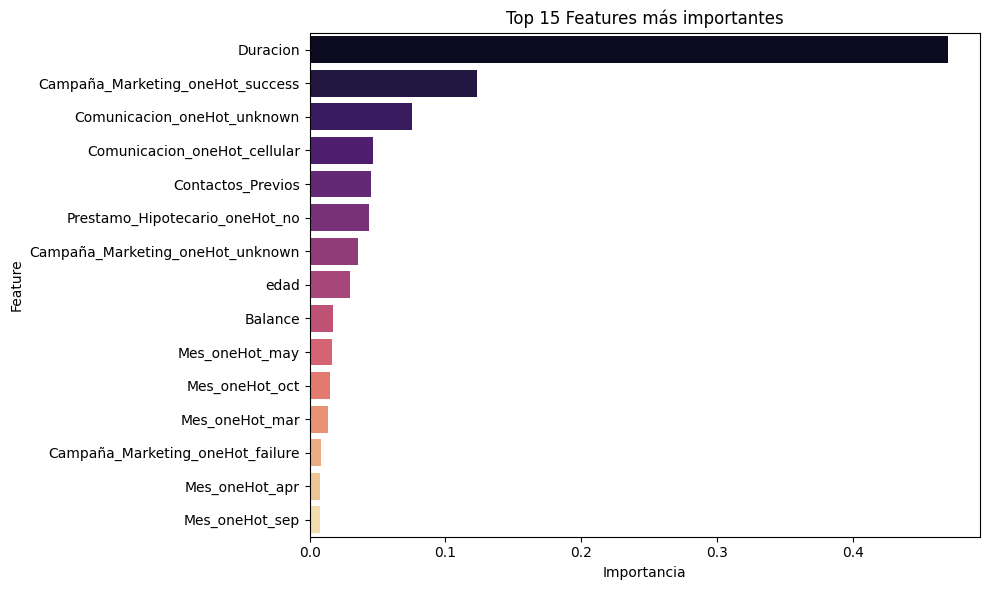

In [100]:
# Grafica de Features mas importantes
importancias = modeloRF.featureImportances
indices      = importancias.indices
valores      = importancias.values

dfImportancia = pd.DataFrame({
    'Feature'    : [nombresFeatures[i] for i in indices],
    'Importancia': valores
}).sort_values('Importancia', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=dfImportancia, x='Importancia', y='Feature',
            palette='magma', hue='Feature', legend=False)
plt.title('Top 15 Features más importantes')
plt.xlabel('Importancia')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Conclusiones generales
- El gráfico de importancia de variables del Random Forest confirma y valida de manera cuantitativa los hallazgos del análisis exploratorio realizado durante el EDA. La duración domina de forma abrumadora con una importancia de ~0.43, más de tres veces la segunda variable más importante, lo que la consolida como el predictor individual más poderoso del modelo. Este resultado se respalda por los boxplots y el pairplot, era la única variable que mostraba una separación clara entre las clases. Sin embargo, es importante recordar la advertencia de fuga de datos: La Duración se conoce una vez finalizada la llamada por lo que en un escenario de predicción previa al contacto debería excluirse del modelo
- En segundo lugar está Campaña_Marketing_oneHot_success con una importancia cercana a 0.12, lo que confirma que el éxito en las anteriores campañas es el predictor categórico más fuerte, tal como se identificó en el análisis de poutcome
- Despues esta  Comunicacion_oneHot_unknown y Comunicacion_oneHot_cellular con importancias de alrededor de 0.07 y 0.04 respectivamente, lo que revela que el canal de contacto tiene más peso predictivo del estimado visualmente en el EDA. Los contactos previos y préstamo hipotecario no aparecen con importancias similares (~0.04), seguidos por campaña marketing (oneHot-unknown), edad y balance con valores decrecientes entre 0.03 y 0.02
- Los meses específicos (mayo, octubre, marzo, abril, septiembre) y el resultado de fracaso de la campaña anterior aparecen en las últimas posiciones, con importancias mínimas cercanas a 0.01, confirmando su bajo poder predictivo individual identificado durante el EDA

# SEGMENTACIÓN DE CLIENTES POR SCORE DE PROBABILIDAD 

In [108]:
from pyspark.sql.functions import udf
from pyspark.sql.types import FloatType

#El modelo GBT, una vez entrenado y validado como el que mejor desempeño tiene global, se aprovecharon las probabilidades de predicción que genera. 
# para convertirlo de un simple clasificador binario. En vez de predecir 
# se sacó la probabilidad únicamente si un cliente suscribirá o no 
# pertenece de forma continua a la clase positiva (valor entre 0 y 1) y se 
# utilizó para dividir la base de clientes en tres segmentos:

#- Alta Prioridad (score ≥ 0.70): clientes con alta certeza de suscribir, a contactar primero
#- Media Prioridad (score entre 0.40 y 0.70): clientes con propensión moderada, a contactar si hay capacidad operativa
#- Baja Prioridad (score < 0.40): clientes con baja propensión, cuyo contacto representa un bajo retorno sobre la inversión

# Se extrae el índice 1 que corresponde a la probabilidad de suscribir
extraerProb = udf(lambda v: float(v[1]), FloatType())

# Se agrega la columna score al DataFrame de predicciones del GBT
predGBT_score = predRF.withColumn("score", extraerProb(F.col("probability")))

In [109]:
predGBT_score = predGBT_score.withColumn(
    "Segmento",
    F.when(F.col("score") >= 0.70, "Alta Prioridad")
     .when(
         (F.col("score") >= 0.40) & (F.col("score") < 0.70),
         "Media Prioridad"
     )
     .otherwise("Baja Prioridad")
)

In [110]:
# Se calcula por segmento:
#- Cantidad de clientes totales
#- Score promedio del segmento
#- Tasa de conversión real (proporción de "yes" reales)
resumenSegmentos = predGBT_score.groupBy("Segmento").agg(
    F.count("label").alias("Cantidad_Clientes"),
    F.round(F.avg("score"), 4).alias("Score_Promedio"),
    F.round(F.avg("label"), 4).alias("Tasa_Conversion_Real")
).toPandas()

# Se ordena de mayor a menor score promedio
resumenSegmentos = resumenSegmentos.sort_values(
    "Score_Promedio",
    ascending=False
)
print(resumenSegmentos.to_string(index=False))

[Stage 1452:==========================================>             (3 + 1) / 4]

       Segmento  Cantidad_Clientes  Score_Promedio  Tasa_Conversion_Real
 Alta Prioridad               2218          0.7928                0.9346
Media Prioridad               8116          0.5797                0.6766
 Baja Prioridad               5633          0.2763                0.0659


# Comentarios
- Los resultados de la segmentación muestran que el modelo GBT tiene una capacidad excepcional de discriminación entre los tres grupos definidos. El segmento de Alta Prioridad (score ≥ 0.70) está formado por 2,218 clientes con un score medio de 0.7928 y una tasa de conversión real del 93.46%, lo que significa que prácticamente 9 de cada 10 clientes clasificados en este grupo suscribieron efectivamente el depósito
- Esto confirma la solidez del modelo: con solo el 13,9% del total de clientes del conjunto de prueba, el banco capturaría casi la totalidad de los suscriptores reales de alta certeza
- Es el segmento con mayor cantidad de clientes, 8.116, con un score promedio de 0.5797 y una tasa de conversión real del 67.66%, es decir que dos de cada tres clientes en este grupo también suscribieron, el segmento de Media Prioridad (score entre 0.40 y 0.70)
- Este segmento representa la zona de decisión del modelo donde la incertidumbre es mayor, pero la tasa de conversión sigue siendo muy superior al promedio original del dataset (11.7%), lo que confirma que incluso en la ultima zona el modelo agrega valor significativo para la priorizar contactos
- El segmento Baja Prioridad (score < 0.40) agrupa a 5,633 clientes con un score promedio de 0.2763 y una tasa de conversión real de apenas el 6.59%, lo que confirma que el modelo está identificando correctamente a los clientes con muy baja propensión a suscribir. Este grupo es de muy bajo retorno de suscripciones, ya que de cada 100 llamadas que se hacen a este grupo sólo 6 o 7 se suscriben


In [111]:
# Se trae al driver (memoria local) solo las columnas necesarias
# para generar las gráficas con matplotlib
scorePandas = predGBT_score.select(
    "score",
    "Segmento",
    "label"
).toPandas()

# Diccionario de colores por segmento para consistencia visual
colors_seg = {
    "Alta Prioridad"  : "green",
    "Media Prioridad" : "gold",
    "Baja Prioridad"  : "red"
}

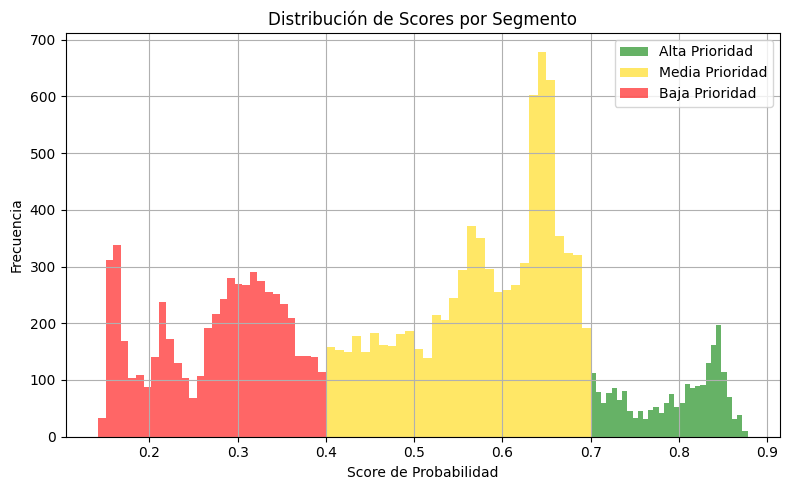

In [112]:
plt.figure(figsize=(8, 5))

# Se grafica un histograma por segmento superpuesto con transparencia para visualizar la separación entre grupos
for segmento, color in colors_seg.items():
    subset = scorePandas[scorePandas["Segmento"] == segmento]["score"]
    plt.hist(subset, bins=30, alpha=0.6, color=color, label=segmento)

plt.xlabel("Score de Probabilidad")
plt.ylabel("Frecuencia")
plt.title("Distribución de Scores por Segmento")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Histograma
- El histograma de scores muestra como la zona roja se concentra entre 0.15 y 0.40 con múltiples picos que reflejan la heterogeneidad de los perfiles de baja propensión, la zona amarilla domina el rango 0.40-0.70 con una distribución más concentrada alrededor de 0.60-0.65 y la zona verde aparece en el rango 0.70-0.90 con una distribución más dispersa pero claramente separada de los otros dos grupos
- La falta de datos entre los extremos verde y rojo se refiere a que el modelo produce puntuaciones bien separadas para los casos más claros, con la ambigüedad concentrada en la zona media

In [ ]:
# Gráfica de barras (de mayor a menor prioridad)
orden = ["Alta Prioridad", "Media Prioridad", "Baja Prioridad"]
colores_barra = ["green", "gold", "red"]

# Se reordena el DataFrame según el orden definido
resumenOrdenado = resumenSegmentos.set_index("Segmento").loc[orden].reset_index()

plt.figure(figsize=(8, 5))
plt.bar(
    resumenOrdenado["Segmento"],
    resumenOrdenado["Tasa_Conversion_Real"] * 100,   # Se convierte a porcentaje
    color=colores_barra
)
plt.xlabel("Segmento")
plt.ylabel("Tasa de Conversión Real (%)")
plt.title("Tasa de Conversión Real por Segmento")
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# gráfica de barras
- Si el banco decidiera contactar solo a los segmentos de Alta y Media Prioridad (10.334 clientes en total, que representa el 64,7% de la base), capturaría prácticamente la totalidad de los suscriptores reales y eliminaría el 35,3% de contactos de menor retorno. Al contactar solo el segmento de Alta Prioridad (2,218 clientes, el 13.9% de la base), se obtendría una tasa de conversión del 93.46%, lo que haría la campaña más eficiente que el enfoque masivo sin segmentación
- Ésta es la mayor prueba de que el modelo no solo permite predecir quién va a suscribir, sino que permite al banco decidir a quién llamar, cuándo y con qué nivel de prioridad, optimizando los recursos operativos y la experiencia del cliente al reducir los contactos no deseados

### **Conclusiones**
- El objetivo del presente trabajo fue diseñar un sistema de clasificación binaria sobre el dataset Bank Marketing de UCI, utilizando Apache Spark como plataforma de procesamiento distribuido, para predecir la probabilidad de que un cliente bancario contrate un depósito a plazo fijo ante una campaña de marketing telefónico. Durante el análisis se hizo todo el ciclo de un proyecto de ciencia de datos, desde la recolección y exploración de datos hasta el entrenamiento, evaluación y comparación de varios modelos de machine learning

- El dataset presentó desde el principio uno de los desafíos más comunes en problemas de clasificación bancaria, un severo desbalance de clases, con el 88,3% de los registros correspondientes a clientes que no suscribieron, y apenas el 11,7% a quienes sí lo hicieron. Este desbalance se abordó mediante oversampling de la clase minoritaria, creando un dataset balanceado con una proporción aproximada de 50/50, lo que permitió entrenar modelos sin que tuvieran inclinación hacia la clase mayoritaria

- El análisis exploratorio muestra que la variable Duracion es el predictor individual más fuerte del dataset, con una separación visual clara entre clases en boxplots, pairplot y una importancia de 0.43 en el Random Forest, aunque su uso en producción requiere precaución por el riesgo de data leakage al tratarse de una variable post-evento. En cuanto al dominio categórico, el resultado de la anterior campaña de marketing (poutcome = éxito) demostró ser el predictor categórico más relevante, con una tasa de conversión superior al 50% para los clientes que respondieron positivamente en campañas anteriores, más del cuádruple del promedio general del dataset

- El análisis cruzado de variables permitió construir el perfil del cliente con mayor probabilidad de suscribir un depósito a plazo: se trata de un cliente que fue contactado con éxito en campañas anteriores, tiene educación universitaria, es jubilado o estudiante, no tiene deudas activas (sin hipoteca ni préstamo personal), fue contactado en meses de baja intensidad de campaña como diciembre, marzo o septiembre, y recibió una llamada de larga duración. Este perfil concentra varios factores que indican una mayor capital disponible, mayor comprensión de productos financieros y mayor receptividad al contacto comercial

- El Gradient Boosted Trees se consolidó como el modelo de mejor desempeño global, alcanzando un AUC-ROC de 0.9122, Accuracy del 83.51%, y el mejor equilibrio entre Falsos Positivos y Falsos Negativos
- La Regresión Logística demostró ser un baseline excepcionalmente competitivo con AUC-ROC de 0.9076, superando al Random Forest en todas las métricas globales. Esto sugiere que las relaciones lineales entre variables como Duracion y la suscripción son lo suficientemente fuertes como para que un modelo lineal bien entrenado compita con otros más complejos

- El Random Forest, aunque el modelo con las métricas globales más bajas, tuvo la menor cantidad de Falsos Negativos (1,047), siendo la mejor opción en el caso de que el objetivo de negocio priorice no perder a ningún cliente con intención real de suscribir por encima de cualquier otra consideración

- El Decision Tree obtuvo el mayor Accuracy de todos con superando incluso al GBT, pero con el AUC-ROC más bajo del grupo competitivo . Esta paradoja ejemplifica una lección crucial en ciencia de datos: una métrica aislada puede ser engañosa, y la evaluación sólida de un modelo de clasificación siempre requiere el análisis conjunto de varias métricas, particularmente el AUC-ROC cuando se trabaja con problemas donde el orden de probabilidades es tan relevante como la decisión binaria

- El Linear SVC alcanzó un AUC-ROC que reforzo la hipótesis de que se planteó durante el EDA sobre la naturaleza predominantemente lineal de las relaciones en el dataset: cuando Duracion explica por sí sola el 43% de la importancia en el Random Forest y tiene una relación casi directa con la suscripción, los modelos que buscan fronteras de decisión lineales como la Regresión Logística y el Linear SVC toman ventaja de esta estructura de una manera muy eficiente, compitiendo en igualdad de condiciones con ensambles mucho más complejos

- El Multilayer Perceptron, aunque el que menor rendimiento global obtuvo con Accuracy de 72.08% y AUC-ROC de 0.7966, aporta una valiosa conclusión metodológica: las redes neuronales son los modelos más sensibles a las condiciones de preprocesamiento y entrenamiento de todos los evaluados. En un escenario con normalización previa, al menos 300 iteraciones de entrenamiento y recursos computacionales adecuados, este modelo podria ser comparable al del grupo líder, convirtiéndolo así en el modelo con mayor potencial de mejora de los seis analizados

- Apache Spark fue una plataforma de procesamiento adecuada para el volumen y la naturaleza del problema. Usar modo clúster con scheduler FAIR, construir un Pipeline de MLlib que encadene codificación categórica, ensamblado de features y entrenamiento en una única estructura reproducible, y guardar modelos en formato Parquet, son prácticas que se escalan directamente a entornos de producción con volúmenes de datos mucho mayores. La combinación de PySpark con herramientas de Python como Pandas, Matplotlib, Seaborn y Scikit-learn permitio que se aprovechara lo mejor de ambos mundos: el poder de procesamiento distribuido de Spark para el manejo de datos y el entrenamiento, y la riqueza visual y estadística de las librerías de Python para el análisis exploratorio y evaluación

In [ ]:
# Cierre de la sesión de Spark al finalizar el notebook
sparkB.stop()
print("Sesión de Spark cerrada correctamente.")